# Ookla EDA — Malaysia Fixed Broadband & Mobile/Cellular (Combined)

Same structure/methodology as the Thailand combined notebook. Shared setup (geo, province/region reference, GDP/tier context) runs once; Part 1 and Part 2 each run an independent full EDA pass over their own dataset (fixed vs mobile Ookla tiles).

**Data sources:** ADM1 boundaries from geoBoundaries (simplified); population/area/density from public sources (Wikipedia); real state-level nominal GDP per capita from DOSM (Dept. of Statistics Malaysia), 2021 (Putrajaya has no published figure and is assumed equal to Kuala Lumpur); compiled into `data/reference/malaysia_reference.csv`. GDP unit: nominal USD, 2021 (World Bank), PPP-adjusted and THB columns derived from it -- see CSV header comment.

Run All top-to-bottom to generate outputs.


### use dataset from this link

# 2023
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=1/2023-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=2/2023-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=3/2023-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=4/2023-10-01_performance_fixed_tiles.parquet

# 2024
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=1/2024-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=2/2024-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=3/2024-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=4/2024-10-01_performance_fixed_tiles.parquet

# 2025
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=1/2025-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=2/2025-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=3/2025-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=4/2025-10-01_performance_fixed_tiles.parquet

### or just place this in cli

```bash
TARGET_DIR="../../data/ookla/raw"
mkdir -p "$TARGET_DIR"

for year in 2023 2024 2025; do
    # Quarter 1 (Jan), Quarter 2 (Apr), Quarter 3 (Jul), Quarter 4 (Oct)
    for q in 1 2 3 4; do
        if [ "$q" -eq 1 ]; then month="01"; fi
        if [ "$q" -eq 2 ]; then month="04"; fi
        if [ "$q" -eq 3 ]; then month="07"; fi
        if [ "$q" -eq 4 ]; then month="10"; fi
        
        URL="https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=${year}/quarter=${q}/${year}-${month}-01_performance_fixed_tiles.parquet"
        echo "Downloading ${year} Q${q}..."
        curl -L "$URL" -o "$TARGET_DIR/${year}-Q${q}_performance_fixed_tiles.parquet"
    done
done
```

### alternative

```bash
aws s3 ls --no-sign-request s3://ookla-open-data/ --recursive
```

### mapping part 

using this as source ```https://github.com/teamookla/ookla-open-data/blob/master/tutorials/python/filter_by_centroids/centroids.ipynb```

In [1]:
# url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### load data

In [3]:
    THAILAND_GEOJSON = '../../data/geo/malaysia_provinces.geojson'

    PROVINCE_COL = 'name' 

    perf_tiles_url = "../../data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet"

    thailand_provinces_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

    # Capture the total bounds of Malaysia's boundaries for the bounding box filter
    state_bounds = thailand_provinces_gdf.total_bounds

In [4]:
metric_name = 'avg_d_kbps'

In [5]:
bbox_filters = [('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
                ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0])]

In [6]:
tiles_df = pd.read_parquet(perf_tiles_url,
                           columns=['tile_x', 'tile_y', 'tests', metric_name],
                           filters=bbox_filters
                           )

FileNotFoundError: [Errno 2] No such file or directory: '../../data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet'

### Create GeoDataFrame from Centroids

In [7]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df, 
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y), 
    crs="EPSG:4326"
).drop(columns=["tile_x", "tile_y"])

# Drop any rows where we're missing values for the metric
tiles_gdf.dropna(subset=[metric_name], inplace=True)

In [8]:
thailand_tiles_gdf = gpd.sjoin(
    tiles_gdf, 
    thailand_provinces_gdf, 
    how="inner", 
    predicate="intersects"
)[[PROVINCE_COL, 'tests', metric_name]]

In [9]:
# 3. Aggregate the Metric per Province
province_stats = (
    thailand_tiles_gdf.groupby([PROVINCE_COL])
    .apply(
        lambda x: pd.Series(
            {"avg_metric_wt": np.average(x[metric_name], weights=x["tests"])}
        ),
        include_groups=False
    )
    .reset_index()
)

# Convert from kbps to Mbps for standard readability
province_stats['avg_metric_wt_mbps'] = province_stats['avg_metric_wt'] / 1000.0

# 4. Re-merge geometries for mapping
province_data = thailand_provinces_gdf[[PROVINCE_COL, 'geometry']].merge(province_stats, on=PROVINCE_COL)

In [10]:
# 5. Split into buckets and Plot the Map
labels = ["0 to 50", "50 to 100", "100 to 200", "200 to 300", "300+"]
province_data['group'] = pd.cut(
    province_data['avg_metric_wt_mbps'],
    bins=(0, 50, 100, 200, 300, 10000),
    right=False,
    labels=labels
)

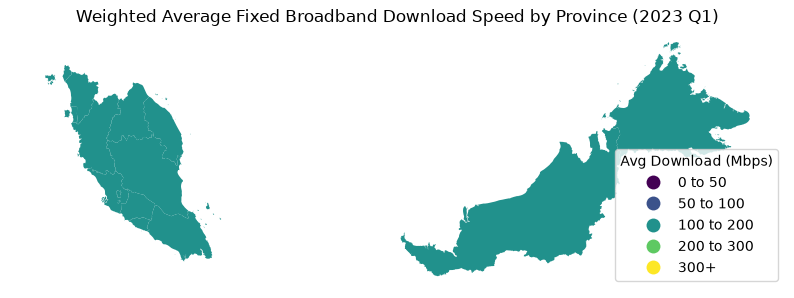

In [11]:
fig, ax = plt.subplots(1, figsize=(10, 8))
province_data.plot("group", ax=ax, legend=True, cmap="viridis", 
                   legend_kwds={'title': "Avg Download (Mbps)", 'loc': 'lower right'})

ax.set_title("Weighted Average Fixed Broadband Download Speed by Province (2023 Q1)")
ax.set_axis_off()

plt.savefig(f'../../outputs/ookla/malaysia/08_province_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import os

file_path = "../../data/ookla/raw"
files = sorted([f for f in os.listdir(file_path) if f.endswith('.parquet')])
print(f"{len(files)} files, reading first for inspection...")

# Read single file to inspect schema — avoid loading 3.7GB at once
df = pd.read_parquet(os.path.join(file_path, files[0]), engine='pyarrow')

23 files, reading first for inspection...


In [13]:
df.head() 

,quadkey,tile,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices
0,0022022300231020,"POLYGON((-178.4619140625 70.9847699889061, -17...",-178.4592,70.9839,87,204,578,3627.0,3312.0,1,1
1,0022133222312322,"POLYGON((-160.02685546875 70.6435894914449, -1...",-160.0241,70.6427,158237,9571,170,517.0,257.0,5,2
2,0022133222330012,"POLYGON((-160.037841796875 70.6399478155463, -...",-160.0351,70.6390,74693,28236,164,590.0,243.0,2,1
3,0022133222330023,"POLYGON((-160.043334960938 70.6363054807905, -...",-160.0406,70.6354,69368,7703,251,546.0,590.0,2,1
4,0022133222330030,"POLYGON((-160.037841796875 70.6381267305321, -...",-160.0351,70.6372,259,260,32,310.0,426.0,1,1


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6336489 entries, 0 to 6336488
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   quadkey          str    
 1   tile             str    
 2   tile_x           float64
 3   tile_y           float64
 4   avg_d_kbps       int64  
 5   avg_u_kbps       int64  
 6   avg_lat_ms       int64  
 7   avg_lat_down_ms  float64
 8   avg_lat_up_ms    float64
 9   tests            int64  
 10  devices          int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 1.7 GB
None


## Province Reference Data

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../data/reference/malaysia_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 16
Regions: ['Borneo / East Malaysia', 'Central', 'East Coast', 'Northern', 'Southern']

    province_en                 region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
          Johor               Southern   4186300              218                771125.44              3
          Kedah               Northern   2217500              233                498386.88              4
       Kelantan             East Coast   1888500              125                329456.96              4
        Malacca               Southern   1047100              629                943118.72              2
Negeri Sembilan                Central   1240100              185                940668.16              2
         Pahang             East Coast   1668200               46                873358.72              3
         Penang               Northern   1800400             1718               1261809.92              2
          Perak               Northern   2569

### Population and GDP by Region — Summary

In [16]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


                        provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                               
Central                         4        10.79       3014.0            1686104.0            1686104.0
Borneo / East Malaysia          3         6.36        393.0            1249293.0            1249293.0
Southern                        2         5.23        424.0             857122.0             857122.0
Northern                        4         6.88        609.0             735217.0             735217.0
East Coast                      3         4.79         89.0             618709.0             618709.0


### GDP per Capita vs Population Density — by Region

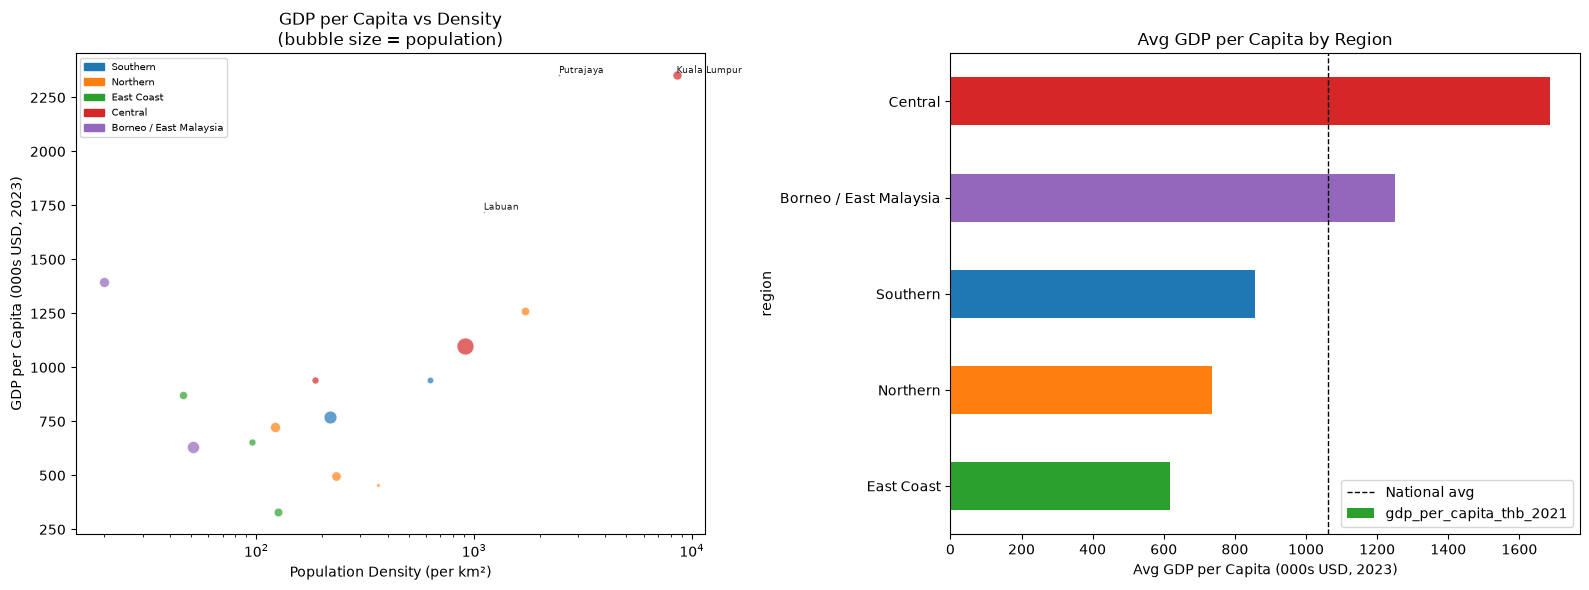

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Southern': '#2a78d6',
    'Northern': '#eb6834',
    'East Coast': '#1baf7a',
    'Central': '#eda100',
    'Borneo / East Malaysia': '#e87ba4',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

# Bar chart: avg GDP per region
r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()


### Internet Tier Distribution — Assumptions Map

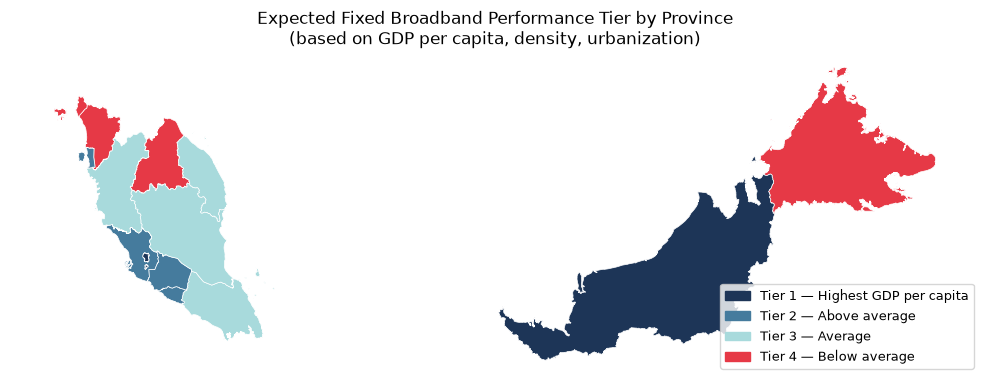

In [18]:
THAILAND_GEOJSON = '../../data/geo/malaysia_provinces.geojson'
thailand_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Merge — GeoJSON uses 'name' column
tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()

# Manual name alignment between GeoJSON and our CSV
name_map = {}  # no manual alignment needed: geojson 'name' already matches reference csv

geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [19]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP 10 by GDP per Capita ===
    province_en                 region  pop_2024  gdp_per_capita_thb_2021  internet_tier
   Kuala Lumpur                Central   2067500               2352939.20              1
      Putrajaya                Central    120300               2352939.20              1
         Labuan Borneo / East Malaysia    100800               1719758.40              1
        Sarawak Borneo / East Malaysia   2518100               1394765.44              1
         Penang               Northern   1800400               1261809.92              2
       Selangor                Central   7363400               1097869.12              2
        Malacca               Southern   1047100                943118.72              2
Negeri Sembilan                Central   1240100                940668.16              2
         Pahang             East Coast   1668200                873358.72              3
          Johor               Southern   4186300                771125.44    

---
# Part 1 — Fixed Broadband


## Full EDA — Ookla Fixed Broadband, Malaysia (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [20]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/malaysia_provinces.geojson'
PROV_REF    = '../../data/reference/malaysia_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_fixed_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*fixed_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   46,454 raw tiles → 16 provinces


  2023-Q2 (2023-04-01):   47,422 raw tiles → 16 provinces


  2023-Q3 (2023-07-01):   47,788 raw tiles → 16 provinces


  2023-Q4 (2023-10-01):   52,450 raw tiles → 16 provinces


  2024-Q1 (2024-01-01):   52,389 raw tiles → 16 provinces


...

  2024-Q3 (2024-07-01):   51,787 raw tiles → 16 provinces


  2024-Q4 (2024-10-01):   50,060 raw tiles → 16 provinces


  2025-Q1 (2025-01-01):   49,281 raw tiles → 16 provinces


  2025-Q2 (2025-04-01):   52,044 raw tiles → 16 provinces


  2025-Q4 (2025-10-01):   53,776 raw tiles → 16 provinces

Master shape: (176, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q4']
Provinces:  16

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-10-01


In [21]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    16
2023-Q2    16
2023-Q3    16
2023-Q4    16
2024-Q1    16
2024-Q2    16
2024-Q3    16
2024-Q4    16
2025-Q1    16
2025-Q2    16
2025-Q4    16

Overall reliable: 176 / 176 (100.0%)


### 2. Data Quality — Coverage per Province

In [22]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 176 | Actual: 176 | Missing: 0

All 176 provinces covered in every quarter.

No quarters with < 100 tests.


In [23]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 176 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

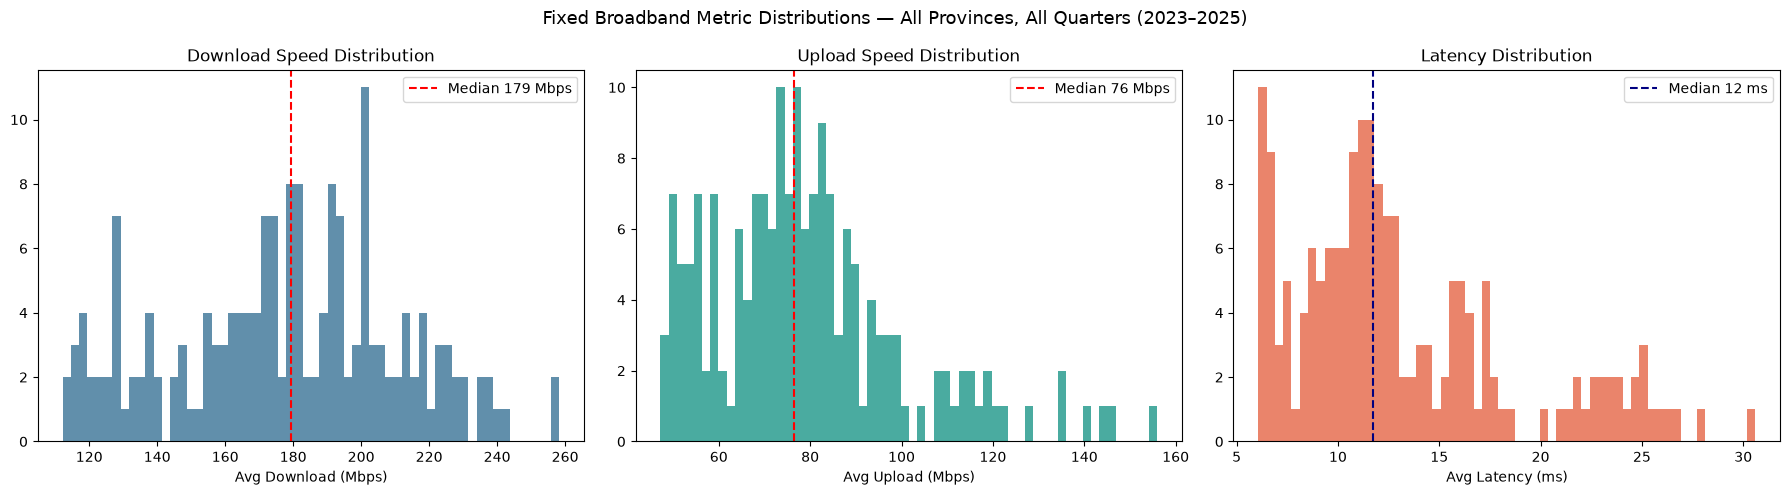

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      176.00      176.00         176.00       176.00
mean       178.02       79.21          13.15     82543.59
std         33.57       21.40           5.56    112081.44
min        112.15       47.23           6.07      1663.00
25%        156.24       65.31           9.38     17675.25
50%        179.32       76.48          11.71     44095.00
75%        200.71       88.36          15.92     90966.25
max        258.31      155.97          30.59    664261.00


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Fixed Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

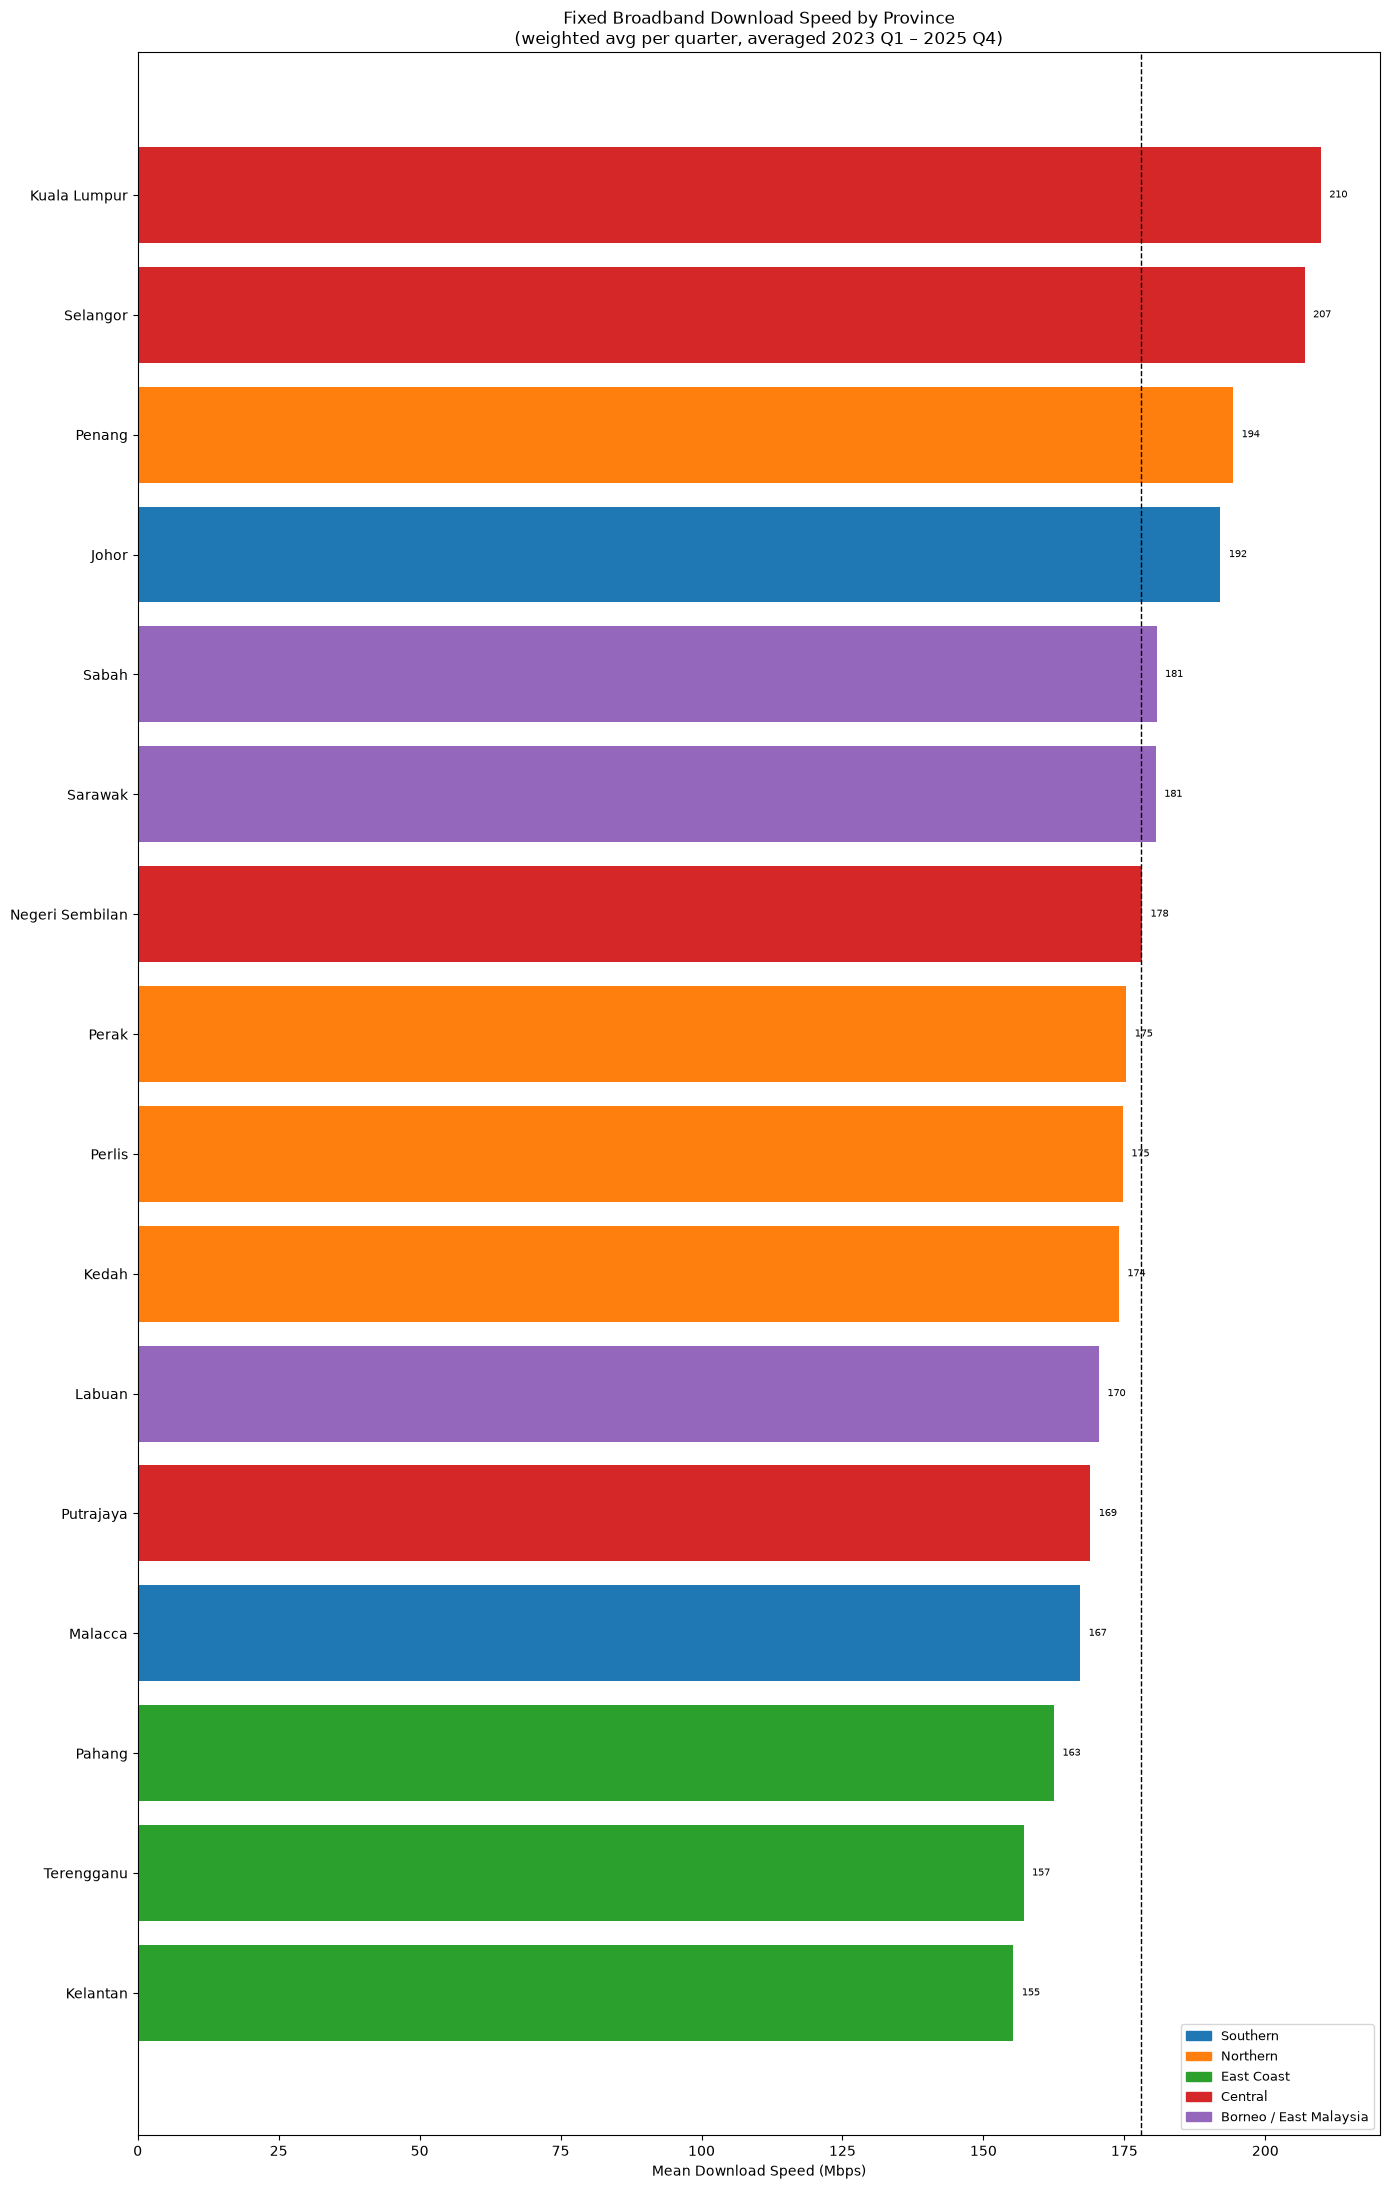

In [25]:
region_colors = {
    'Southern': '#2a78d6',
    'Northern': '#eb6834',
    'East Coast': '#1baf7a',
    'Central': '#eda100',
    'Borneo / East Malaysia': '#e87ba4',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

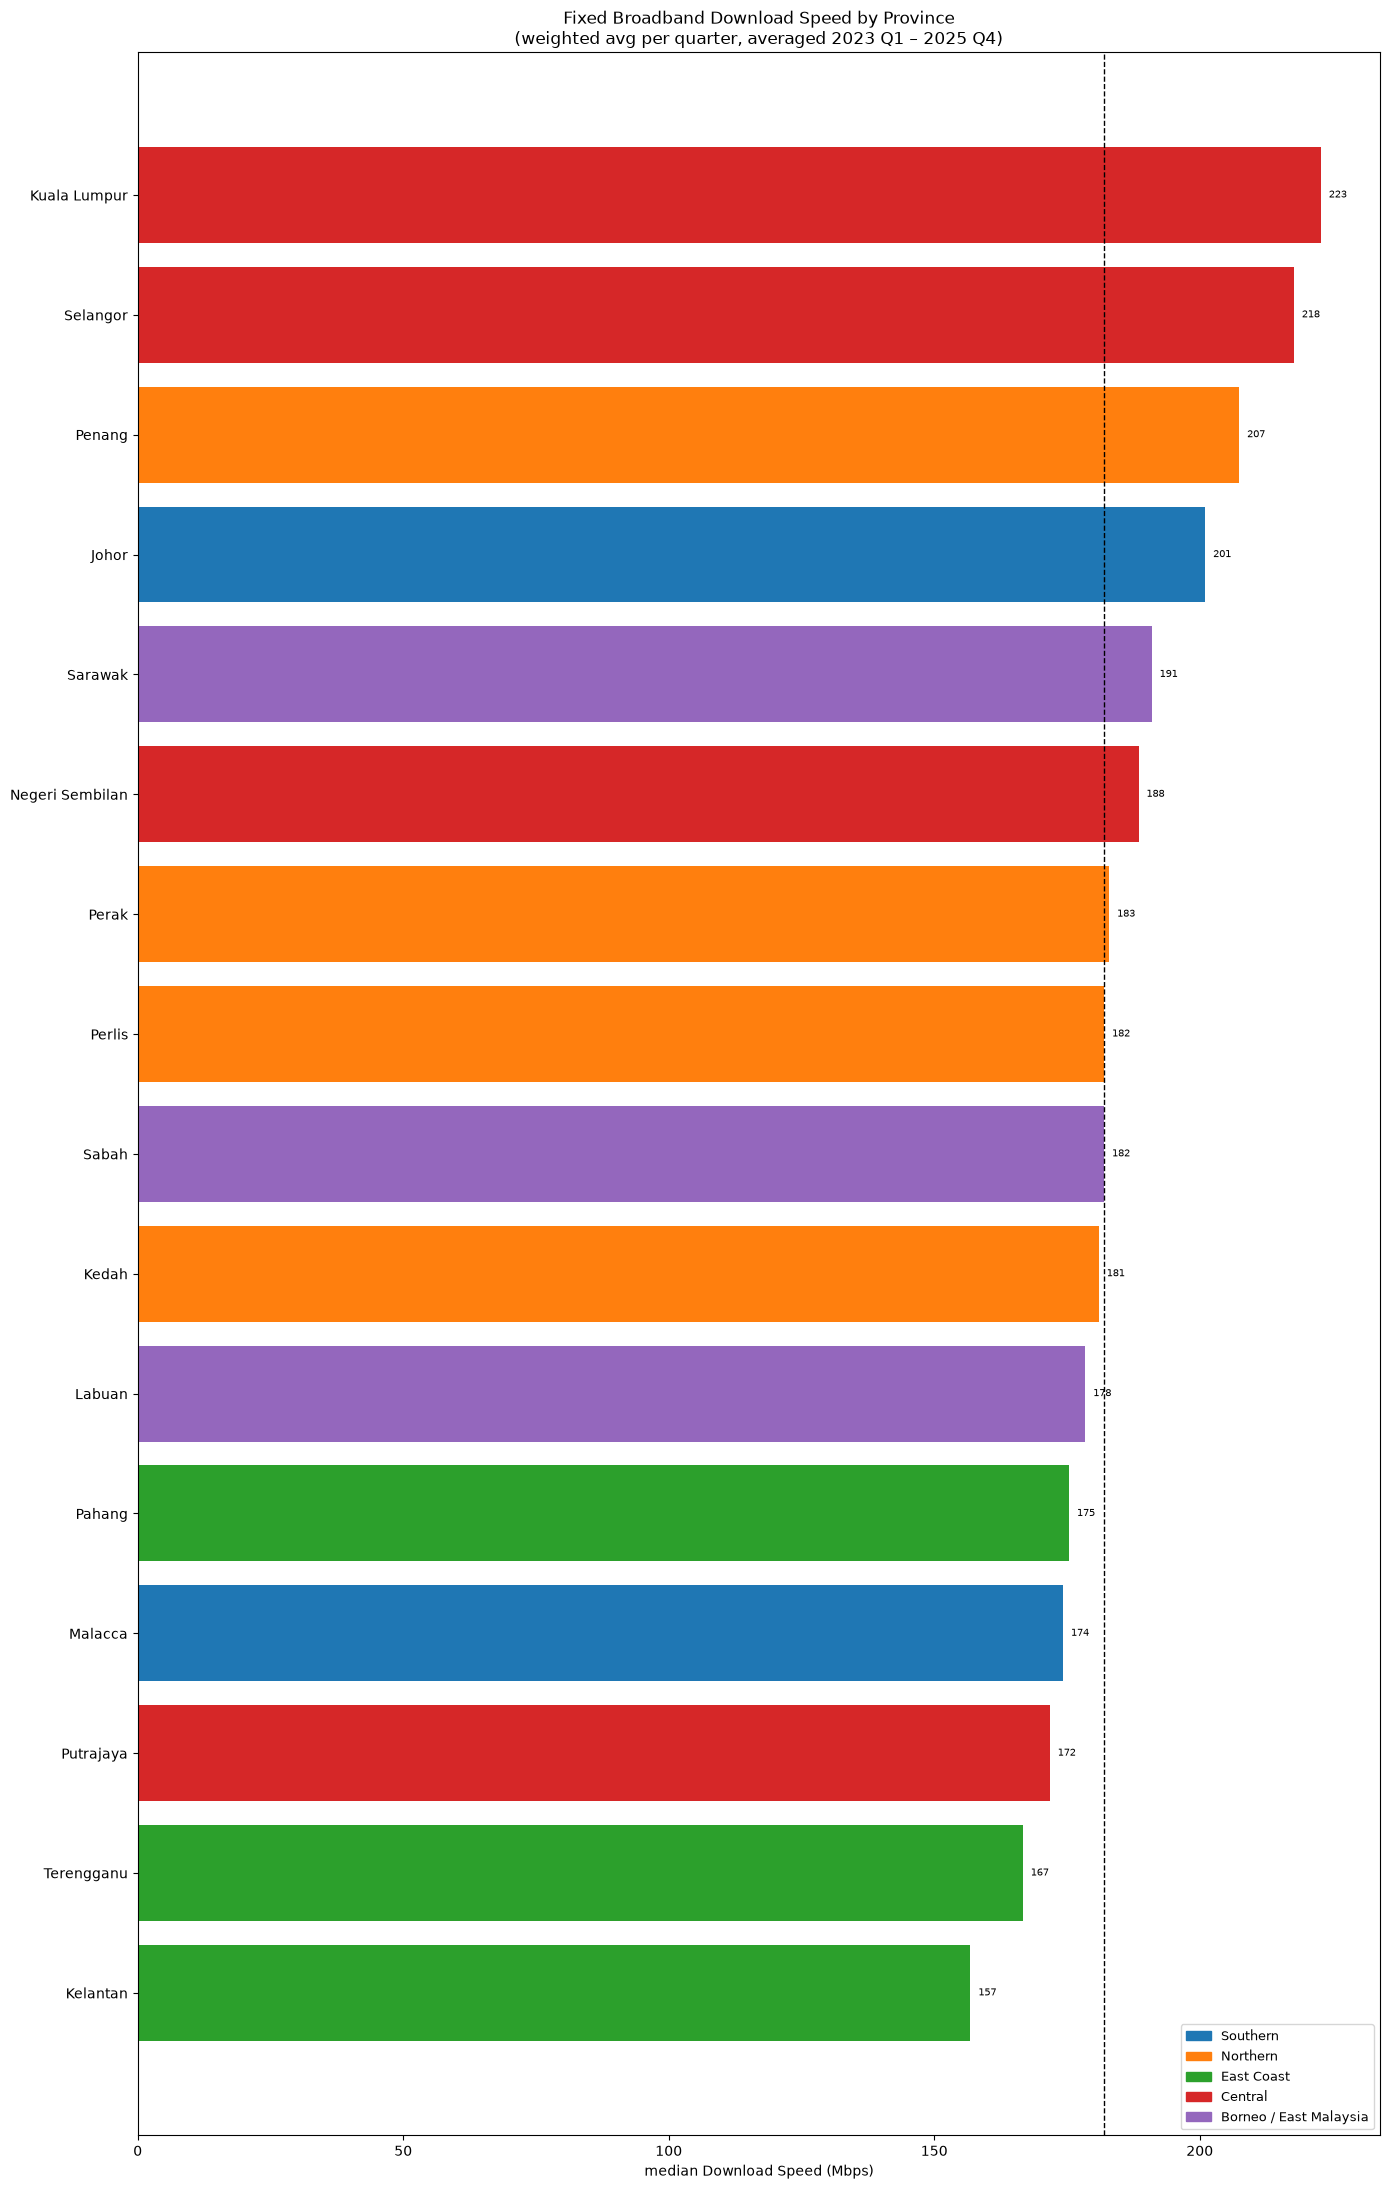

In [26]:
region_colors = {
    'Southern': '#2a78d6',
    'Northern': '#eb6834',
    'East Coast': '#1baf7a',
    'Central': '#eda100',
    'Borneo / East Malaysia': '#e87ba4',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

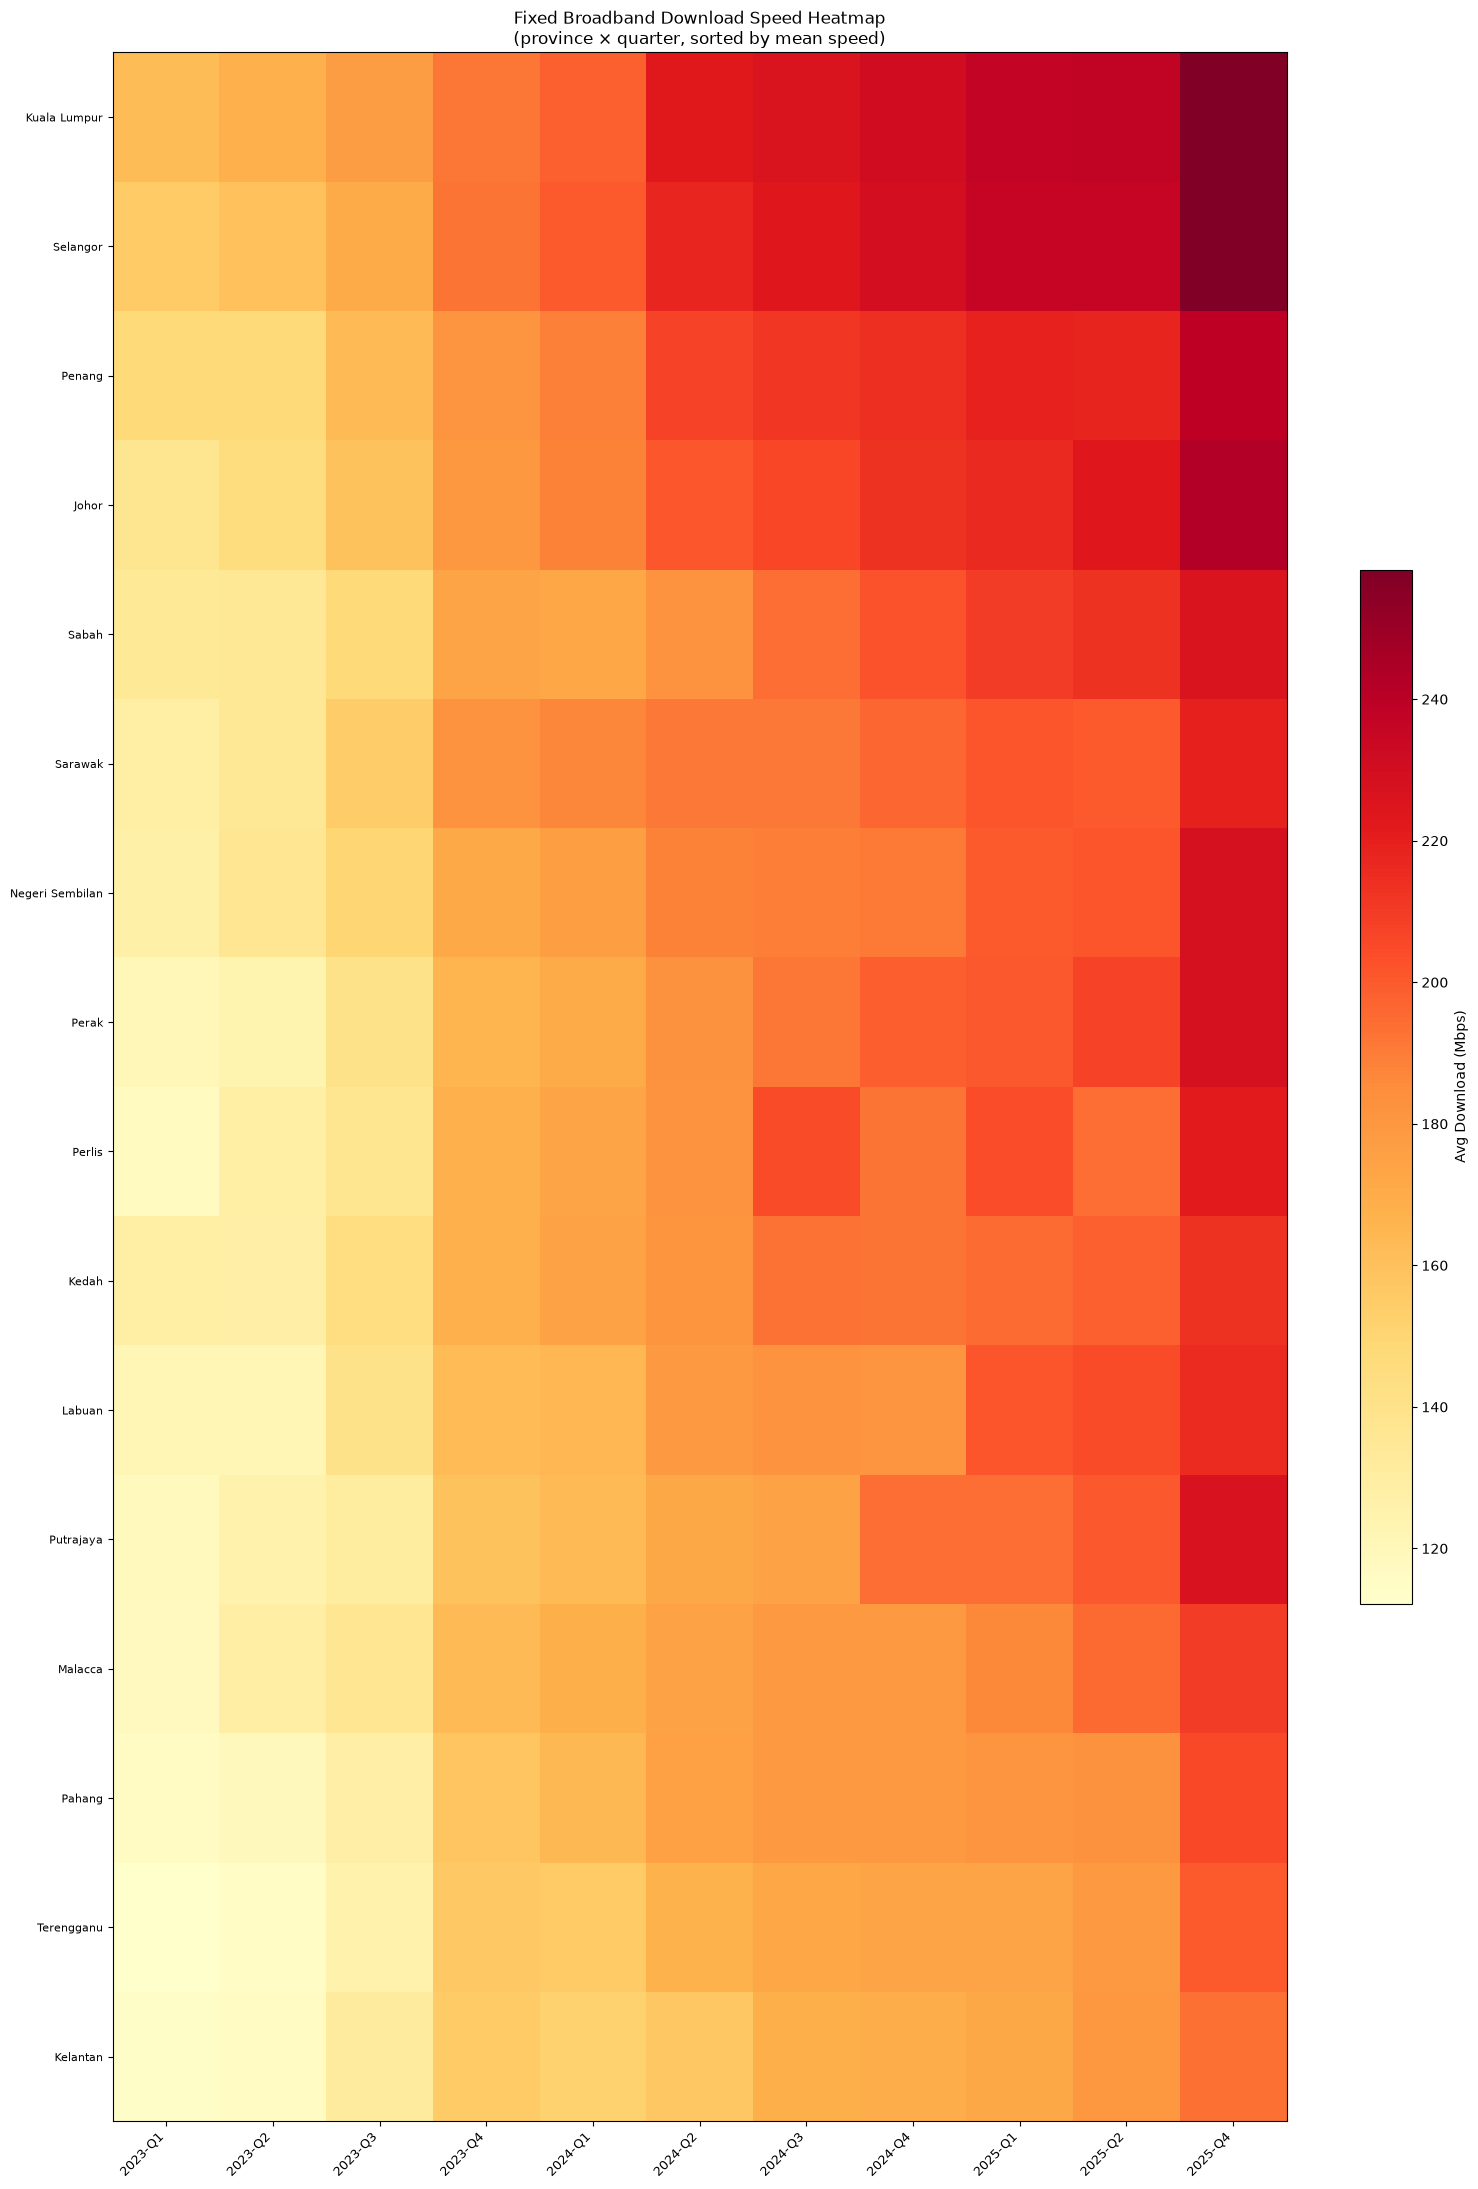

In [27]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Fixed Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

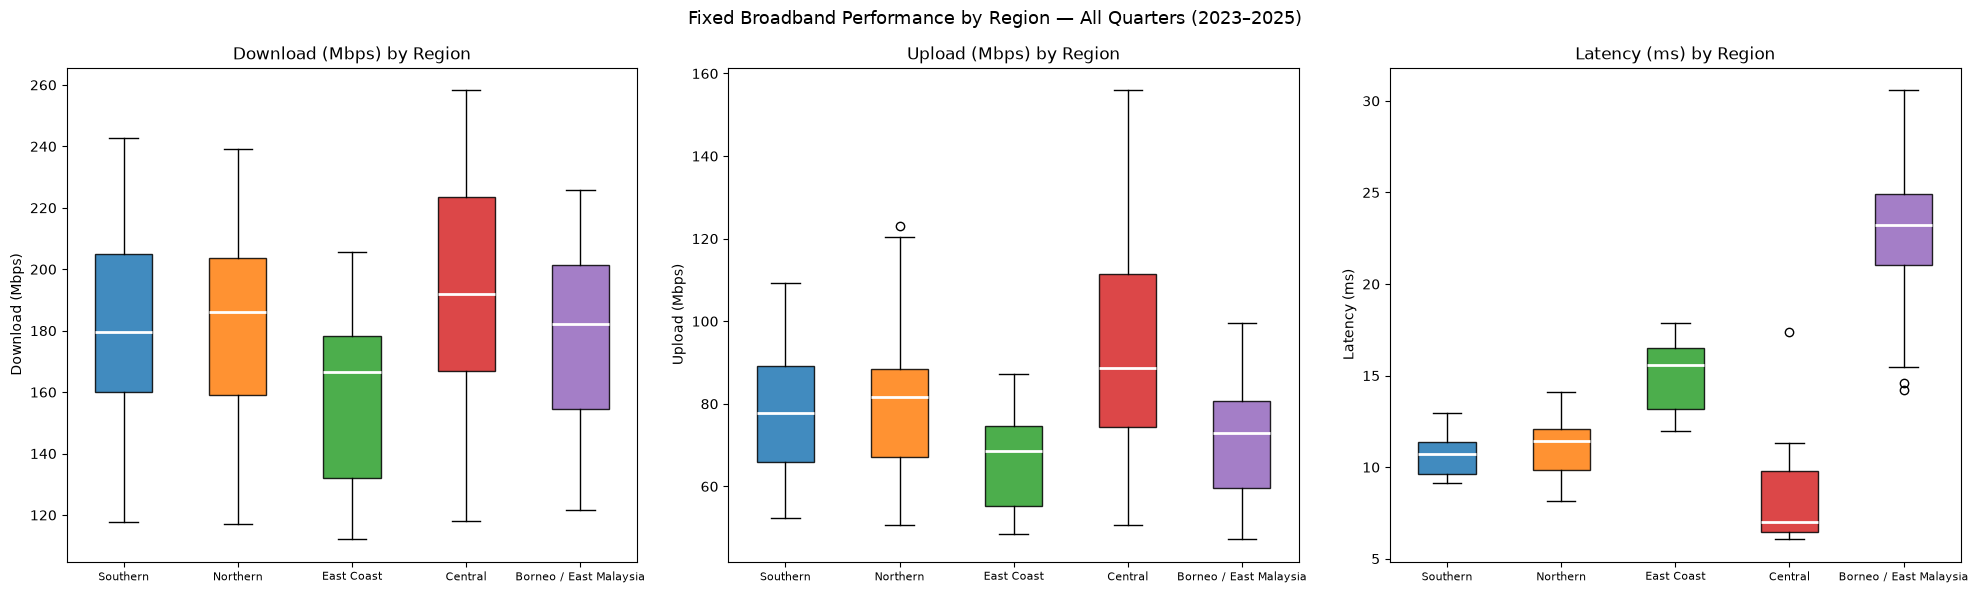

In [28]:
region_order = ['Southern', 'Northern', 'East Coast', 'Central', 'Borneo / East Malaysia']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Fixed Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

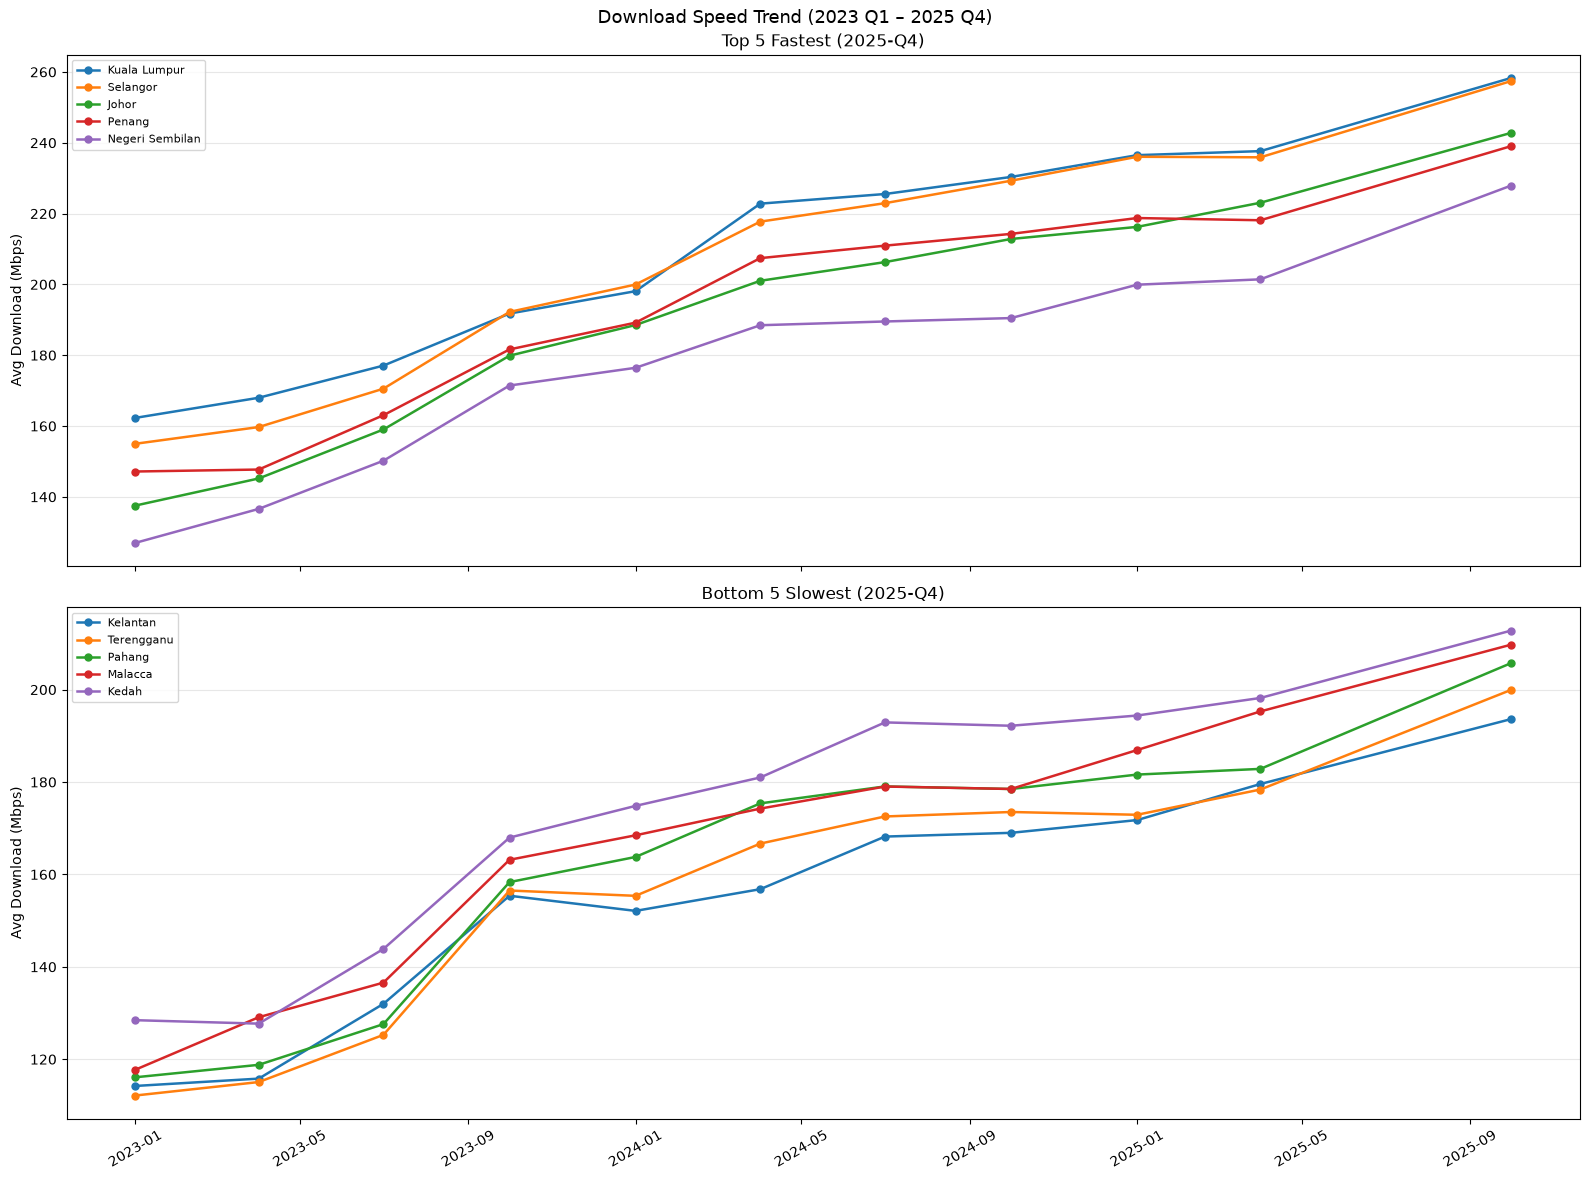

In [29]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

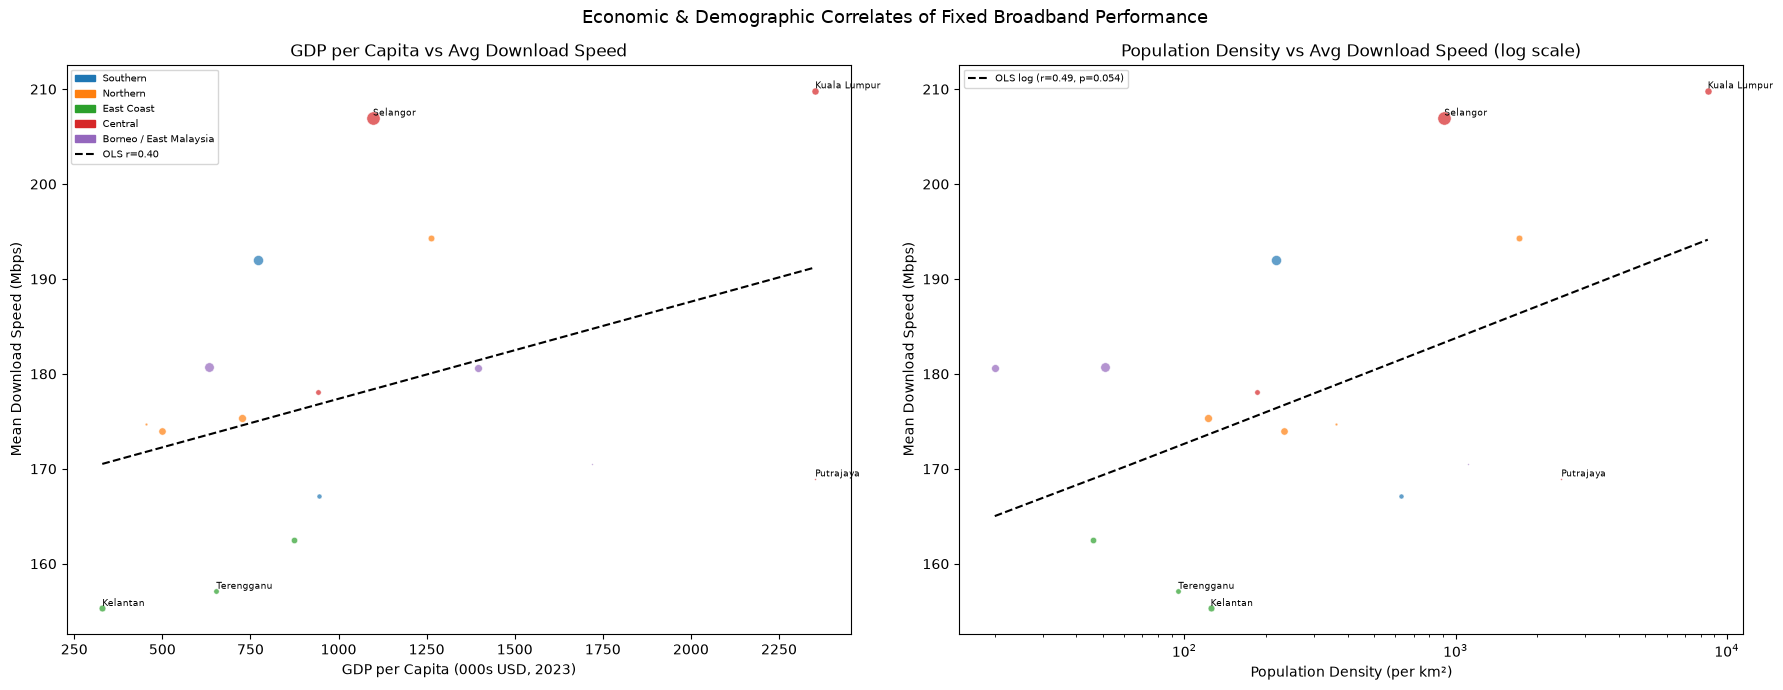

Pearson r (GDP vs download):     0.398  p=0.1272
Pearson r (log density vs download): 0.491  p=0.0536


In [30]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Fixed Broadband Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together


In [31]:
import statsmodels.formula.api as smf

model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
model_df['log_density'] = np.log1p(model_df['density_per_km2'])

terms = []
if model_df['log_gdp'].nunique() > 1:
    terms.append('log_gdp')
if model_df['log_density'].nunique() > 1:
    terms.append('log_density')
if model_df['internet_tier'].nunique() > 1:
    terms.append("C(internet_tier)")
if model_df['region'].nunique() > 1:
    terms.append('C(region)')

formula = 'mean_dl ~ ' + ' + '.join(terms)
mv_model = smf.ols(formula, data=model_df).fit()
print(mv_model.summary())

print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                 -0.061
Method:                 Least Squares   F-statistic:                    0.9035
Date:                Mon, 20 Jul 2026   Prob (F-statistic):              0.572
Time:                        17:59:07   Log-Likelihood:                -59.631
No. Observations:                  16   AIC:                             139.3
Df Residuals:                       6   BIC:                             147.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

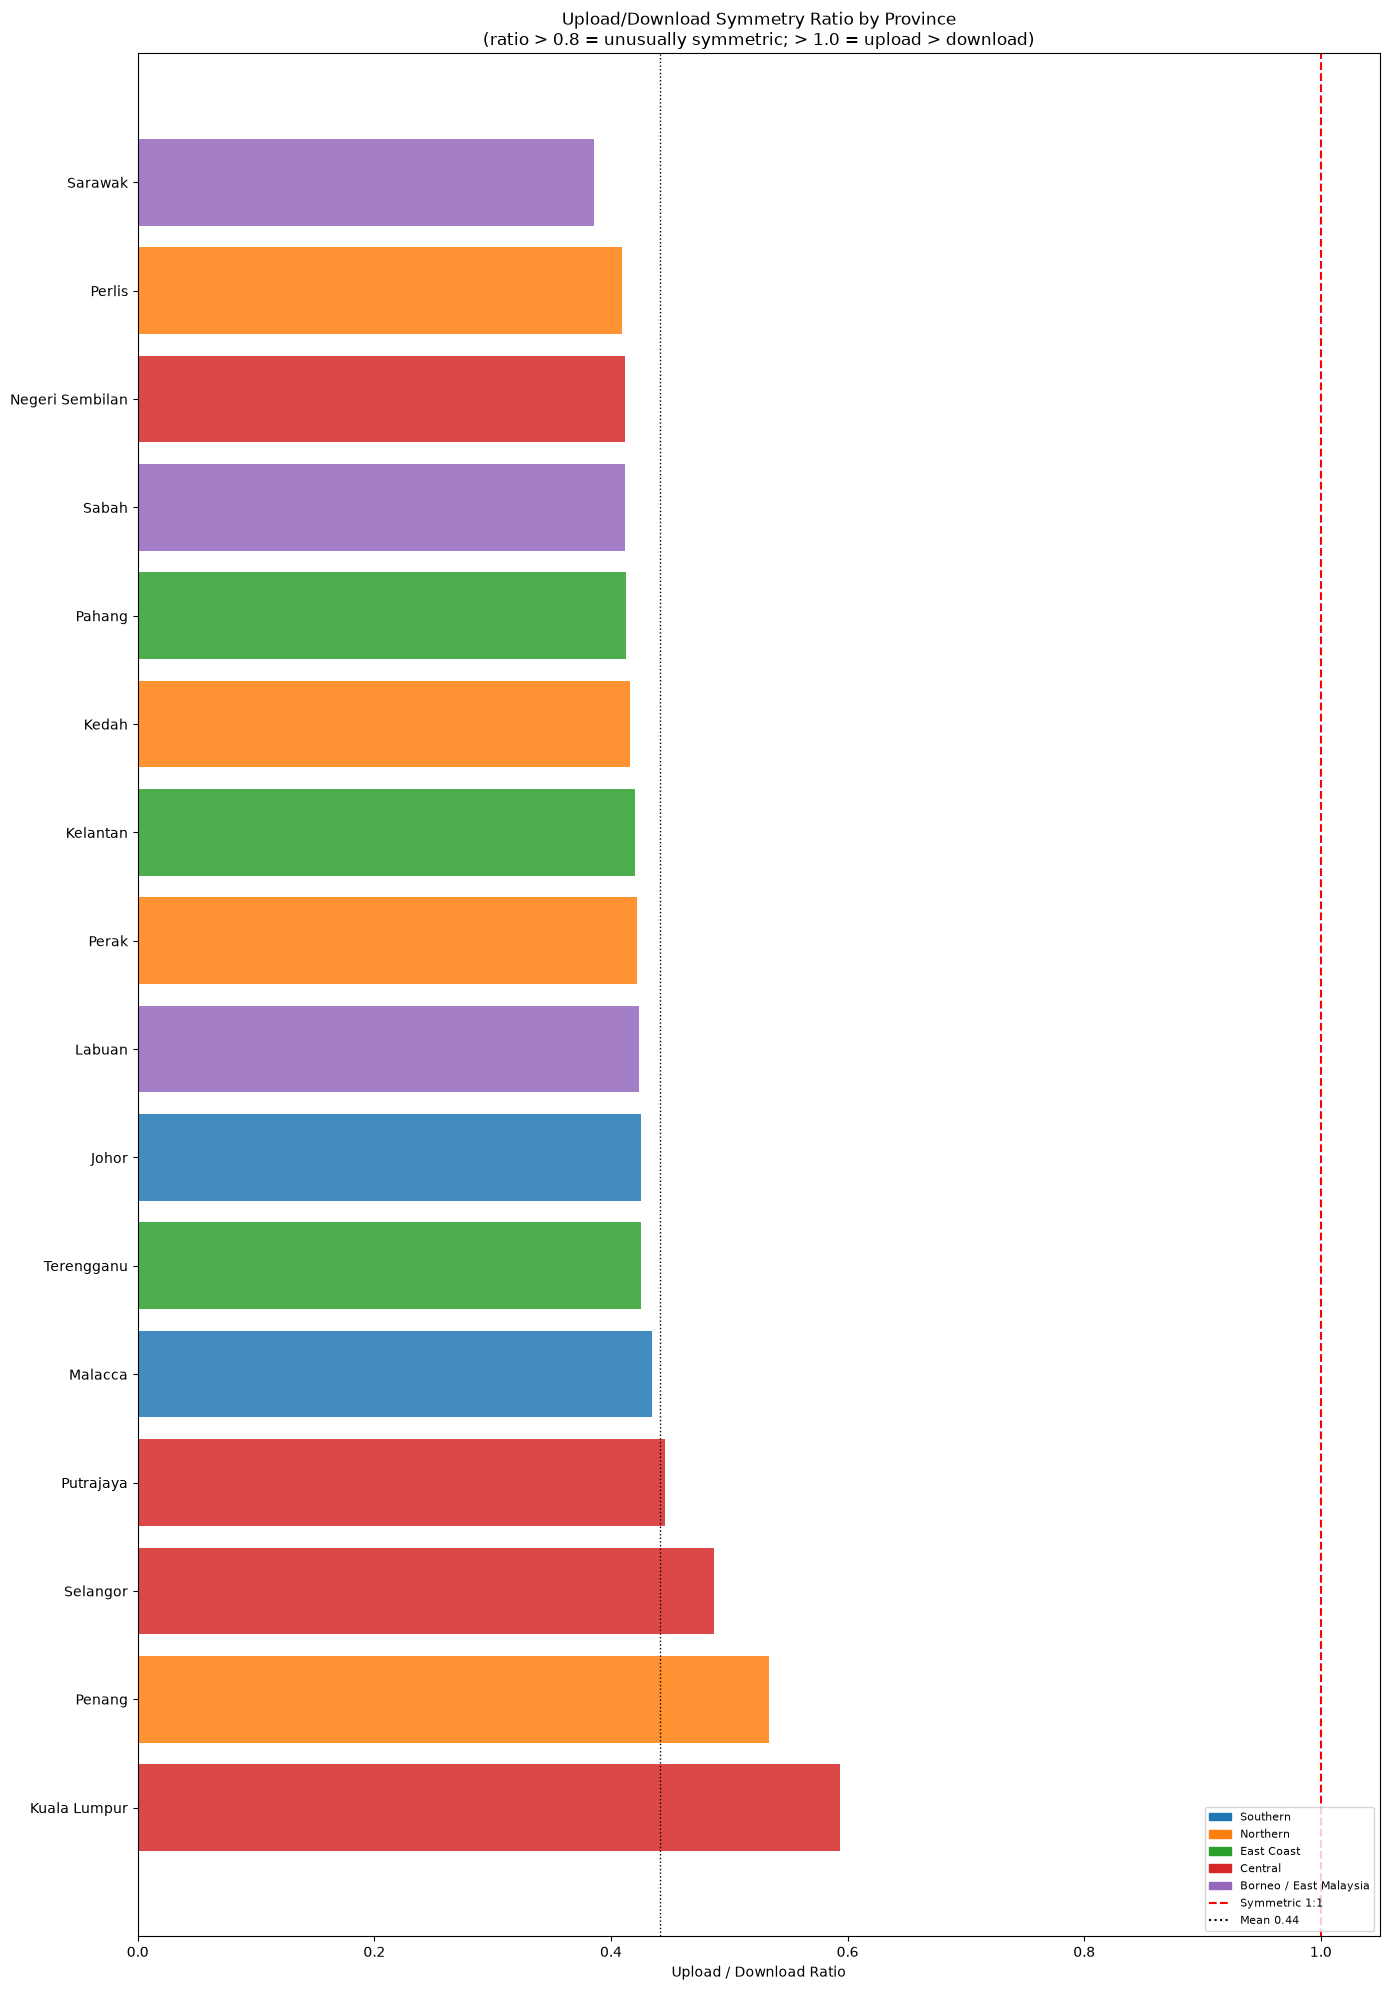

Provinces with UL/DL ratio > 0.8 (0):
Empty DataFrame
Columns: [name, region, ul_dl_ratio]
Index: []


In [32]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [33]:
# Per-province summary stats used by later sections (UL/DL ratio, tier median)

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


### 12. Full Province Summary Table

In [34]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

           name                 region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
   Kuala Lumpur                Central              1   209.85   124.91      6.30         0.59   177806.18               2352939.20
       Selangor                Central              2   206.98   101.15      6.73         0.49   453662.64               1097869.12
         Penang               Northern              2   194.30   103.45      8.75         0.53   103893.55               1261809.92
          Johor               Southern              3   192.04    82.10     11.62         0.43   170024.91                771125.44
          Sabah Borneo / East Malaysia              4   180.72    74.67     25.36         0.41    51159.36                633355.84
        Sarawak Borneo / East Malaysia              1   180.58    69.65     23.29         0.39    64093.55               1394765.44
Negeri Sembilan                Central              2   178.13    73.51     

### 13. UL/DL Symmetry — Fiber Penetration Evidence

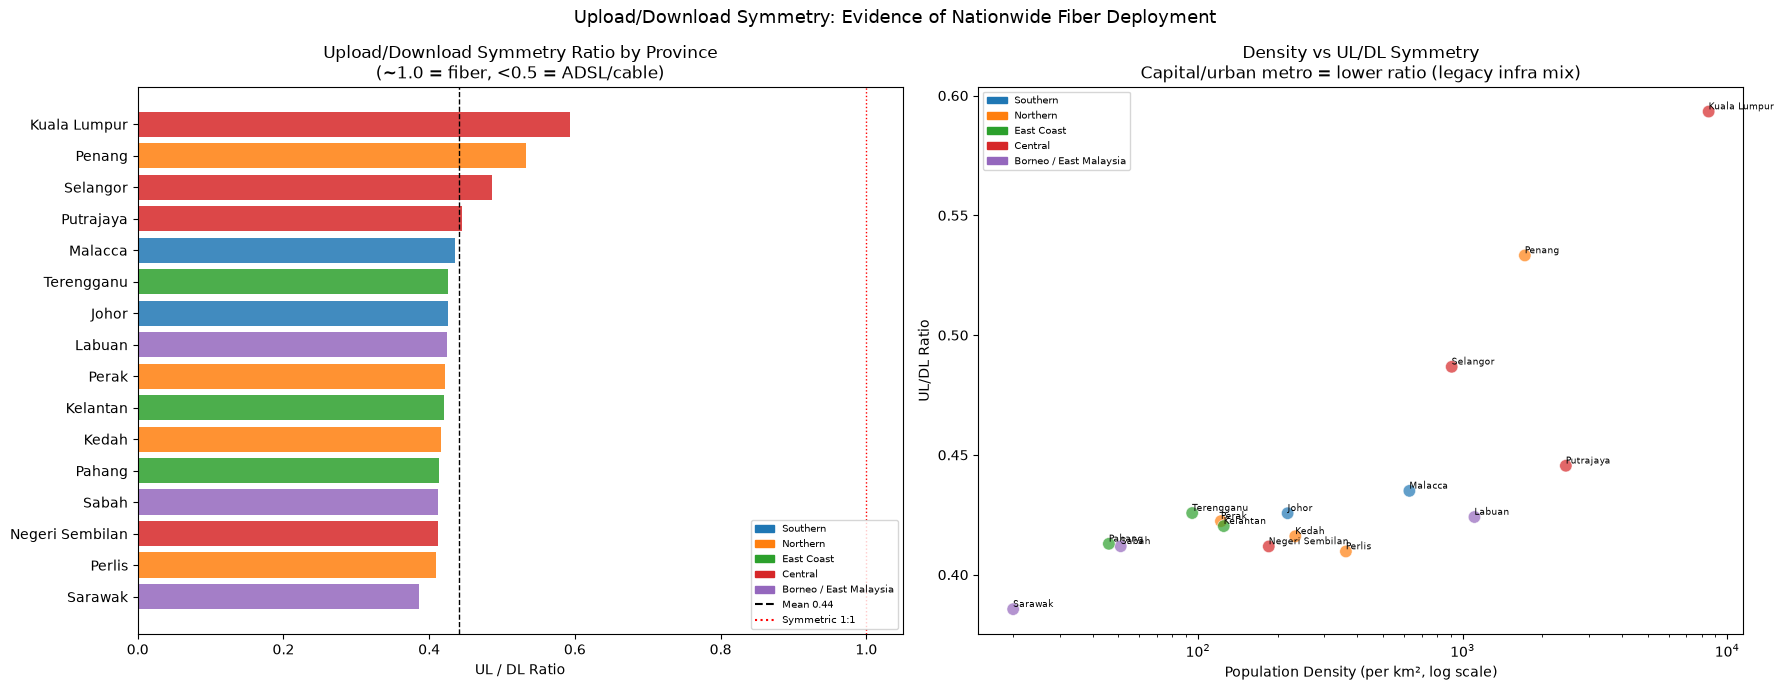

Provinces ratio > 0.90: 0 (near-perfect fiber)
Provinces ratio > 0.80: 0 out of 16
Central min ratio: 0.412
East Coast max ratio: 0.426


In [35]:
# Near-symmetric UL/DL often indicates fiber (GPON/FTTH ~1:1) vs legacy copper (ADSL ~0.1-0.2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(~1.0 = fiber, <0.5 = ADSL/cable)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > 0.91 or row['mean_ratio'] < 0.81 or row['mean_dl'] > 300:
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\nCapital/urban metro = lower ratio (legacy infra mix)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Evidence of Nationwide Fiber Deployment', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.90: {(prov_mean['mean_ratio'] > 0.90).sum()} (near-perfect fiber)")
print(f"Provinces ratio > 0.80: {(prov_mean['mean_ratio'] > 0.80).sum()} out of {len(prov_mean)}")
print(f"{_top_region} min ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].min():.3f}")
print(f"{_bot_region} max ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].max():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

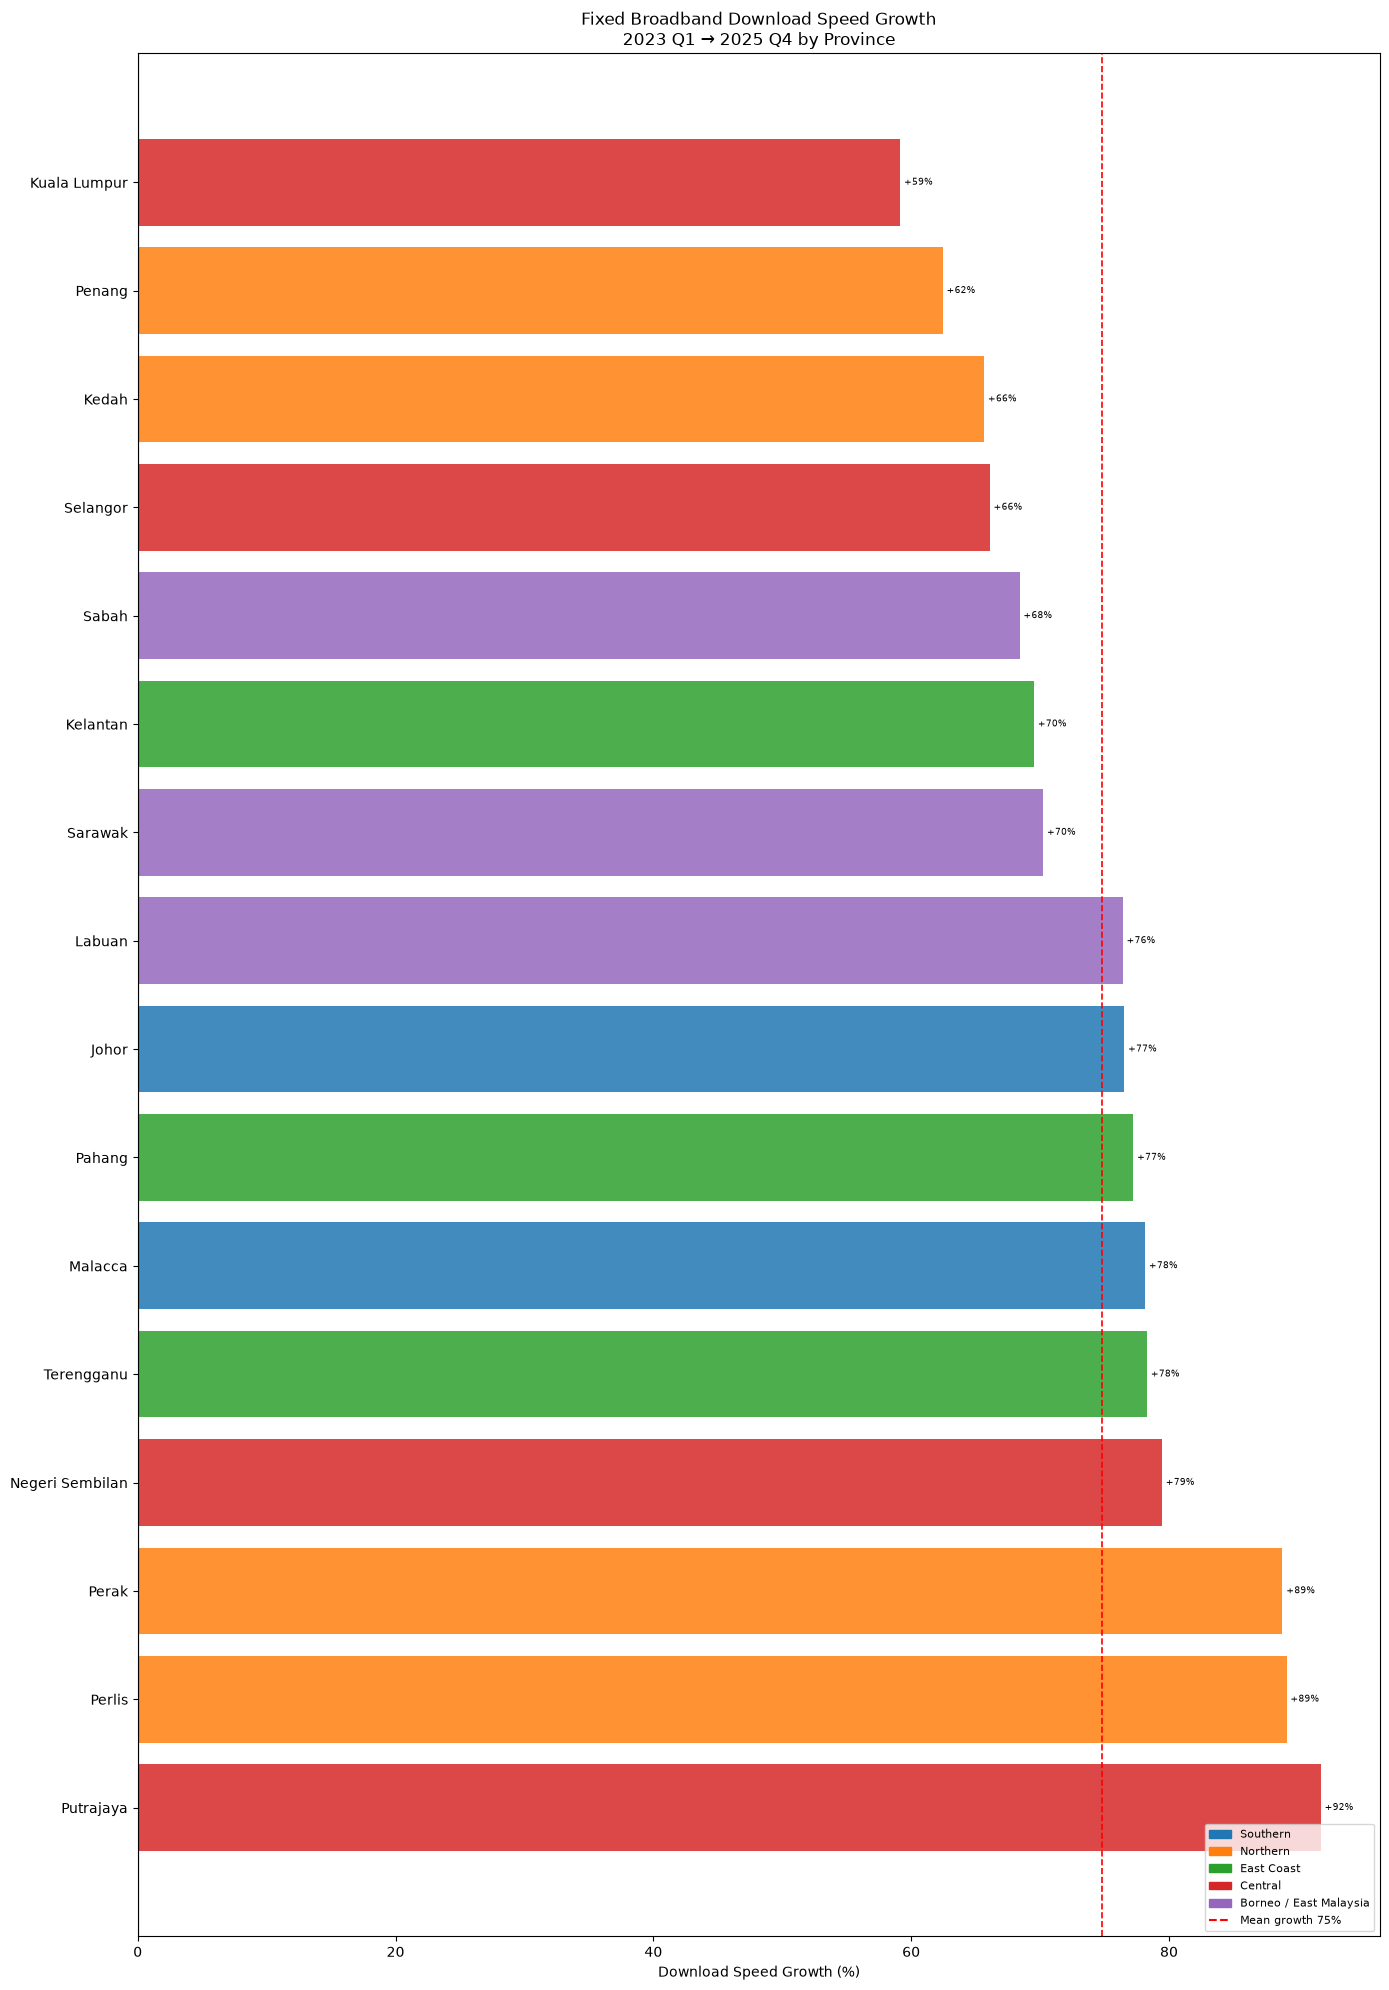

Top 10 fastest growing provinces:
           name                 region  internet_tier  pct_growth
      Putrajaya                Central              1   91.778112
         Perlis               Northern              4   89.123293
          Perak               Northern              3   88.803434
Negeri Sembilan                Central              2   79.456059
     Terengganu             East Coast              3   78.297465
        Malacca               Southern              2   78.146982
         Pahang             East Coast              3   77.230034
          Johor               Southern              3   76.531206
         Labuan Borneo / East Malaysia              1   76.412701
        Sarawak Borneo / East Malaysia              1   70.241232

Bottom 5 (slowest growth or decline):
        name                 region  internet_tier  pct_growth
Kuala Lumpur                Central              1   59.151446
      Penang               Northern              2   62.450049
       Kedah

In [36]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Fixed Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/20_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 16. EDA Key Findings Summary

## Key Findings from EDA

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [47]:
# ── Export Ookla quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_malaysia_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 176 rows → ../../data/exports/ookla_malaysia_province_quarterly.csv
   province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable      region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0     Johor  2023-Q1  2023        1  137.540864   58.244603      11.371712     170444.0   5020.0         True    Southern              3   4186300                771125.44              218
1     Kedah  2023-Q1  2023        1  128.452329   53.794241      11.099864      50058.0   2840.0         True    Northern              4   2217500                498386.88              233
2  Kelantan  2023-Q1  2023        1  114.217230   50.284530      15.560008      23980.0   2170.0         True  East Coast              4   1888500                329456.96              125


---
# Part 2 — Mobile/Cellular


## Full EDA — Ookla Mobile/Cellular, Malaysia (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [48]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/malaysia_provinces.geojson'
PROV_REF    = '../../data/reference/malaysia_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_mobile_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*mobile_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   64,294 raw tiles → 16 provinces


  2023-Q2 (2023-04-01):   65,814 raw tiles → 16 provinces


  2023-Q3 (2023-07-01):   66,206 raw tiles → 16 provinces


  2023-Q4 (2023-10-01):   68,057 raw tiles → 16 provinces


  2024-Q1 (2024-01-01):   67,656 raw tiles → 16 provinces


...

  2024-Q4 (2024-10-01):   66,161 raw tiles → 16 provinces


  2025-Q1 (2025-01-01):   65,665 raw tiles → 16 provinces


  2025-Q2 (2025-04-01):   66,831 raw tiles → 16 provinces


  2025-Q3 (2025-07-01):   65,588 raw tiles → 16 provinces


  2025-Q4 (2025-10-01):   67,367 raw tiles → 16 provinces

Master shape: (192, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  16

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-07-01
  2025-10-01


In [49]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    16
2023-Q2    16
2023-Q3    16
2023-Q4    16
2024-Q1    16
2024-Q2    16
2024-Q3    16
2024-Q4    16
2025-Q1    16
2025-Q2    16
2025-Q3    16
2025-Q4    16

Overall reliable: 192 / 192 (100.0%)


### 2. Data Quality — Coverage per Province

In [50]:
# Expected: 16 provinces × 12 quarters = 192 rows
expected = len(prov_ref) * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 192 | Actual: 192 | Missing: 0

All 192 provinces covered in every quarter.

No quarters with < 100 tests.


In [51]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 192 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

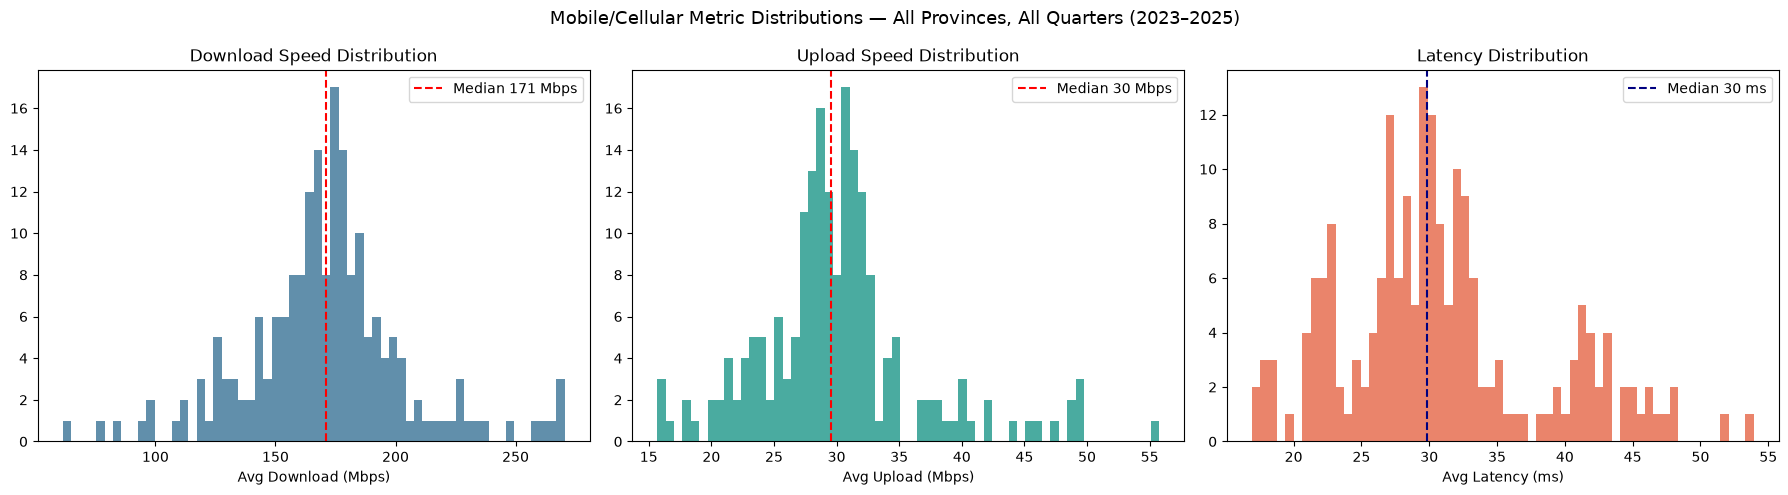

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      192.00      192.00         192.00       192.00
mean       170.85       30.07          30.82     61367.29
std         33.59        6.51           7.44     53304.44
min         61.43       15.69          16.93      2100.00
25%        154.99       27.21          26.69     29179.25
50%        171.19       29.58          29.86     51881.00
75%        184.83       32.02          33.44     78280.75
max        270.39       55.76          53.93    275910.00


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

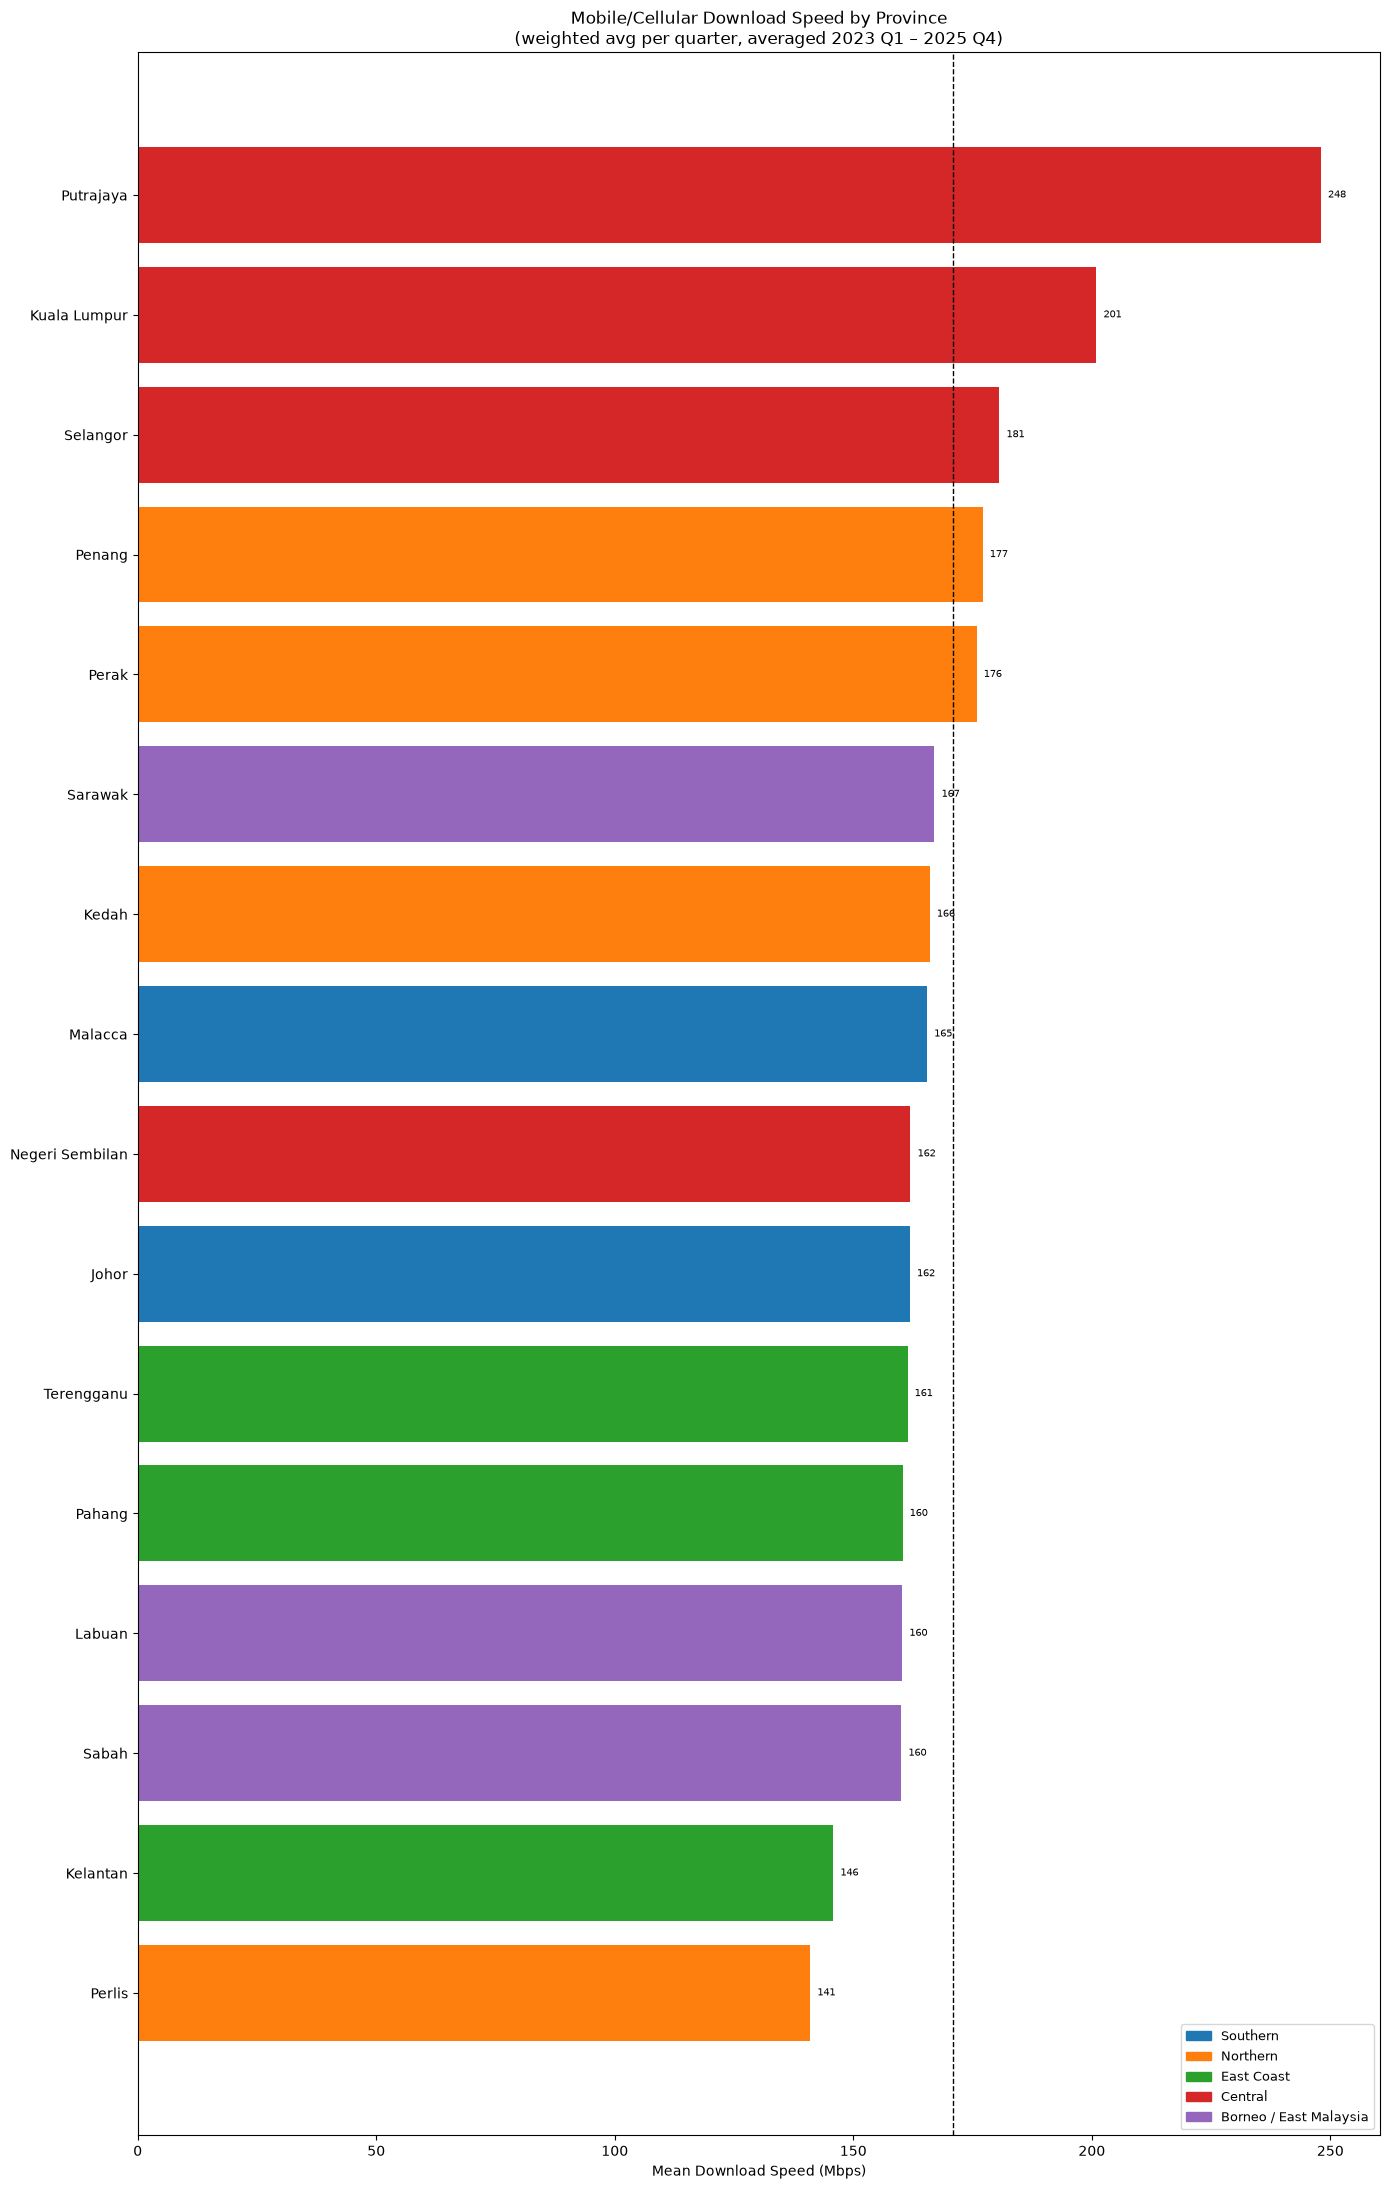

In [53]:
region_colors = {
    'Southern': '#2a78d6',
    'Northern': '#eb6834',
    'East Coast': '#1baf7a',
    'Central': '#eda100',
    'Borneo / East Malaysia': '#e87ba4',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

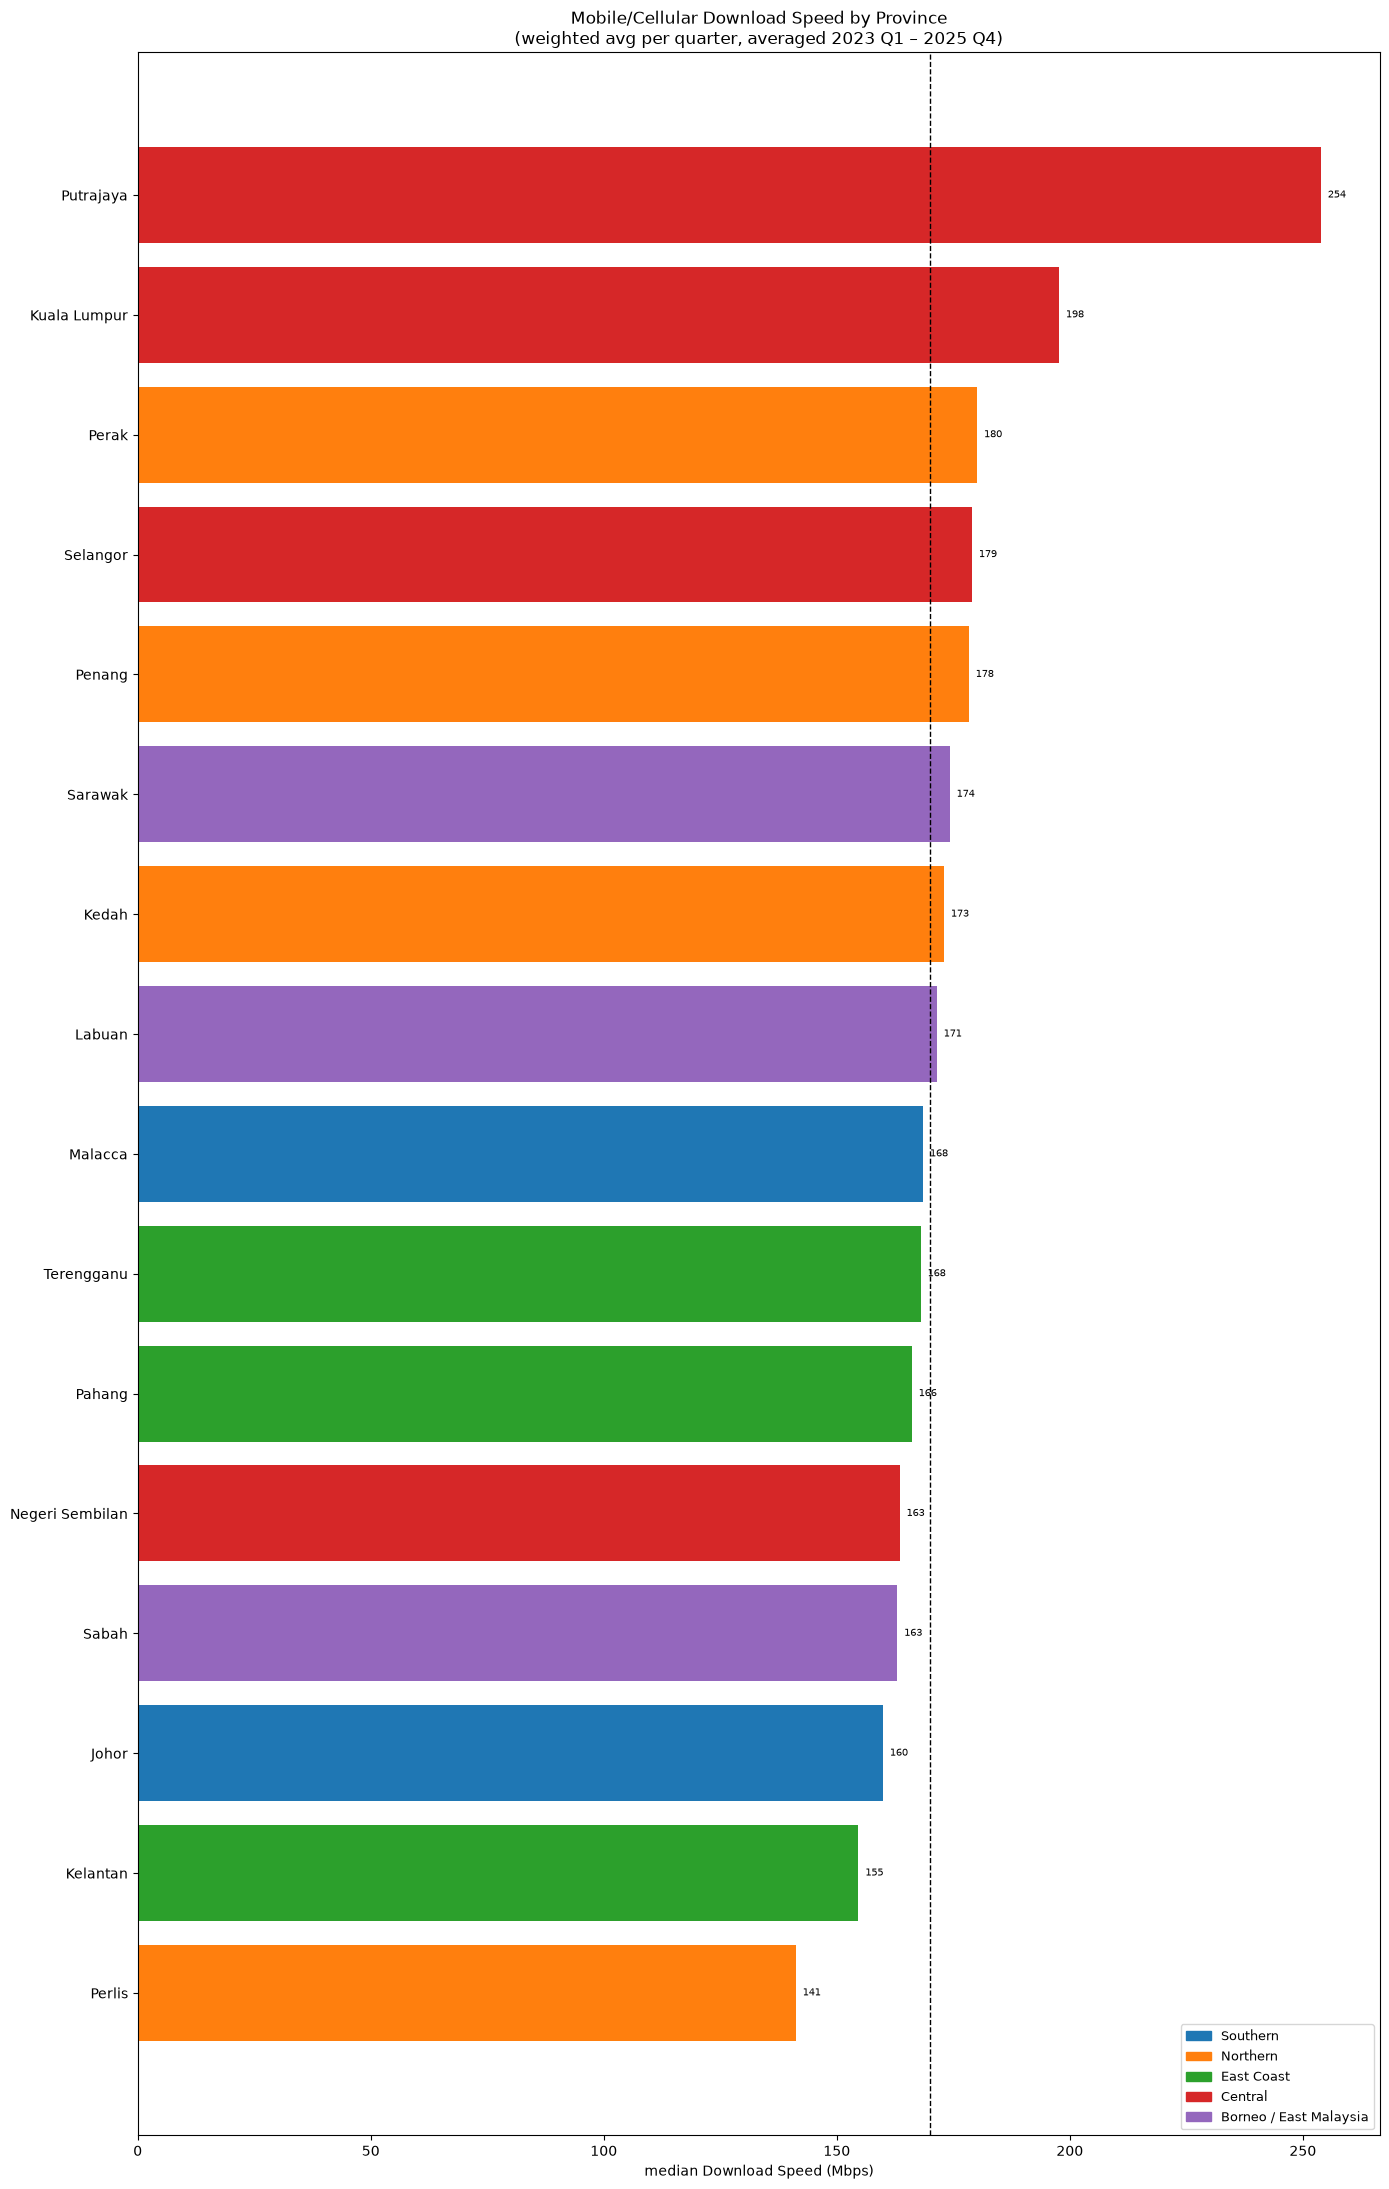

In [54]:
region_colors = {
    'Southern': '#2a78d6',
    'Northern': '#eb6834',
    'East Coast': '#1baf7a',
    'Central': '#eda100',
    'Borneo / East Malaysia': '#e87ba4',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

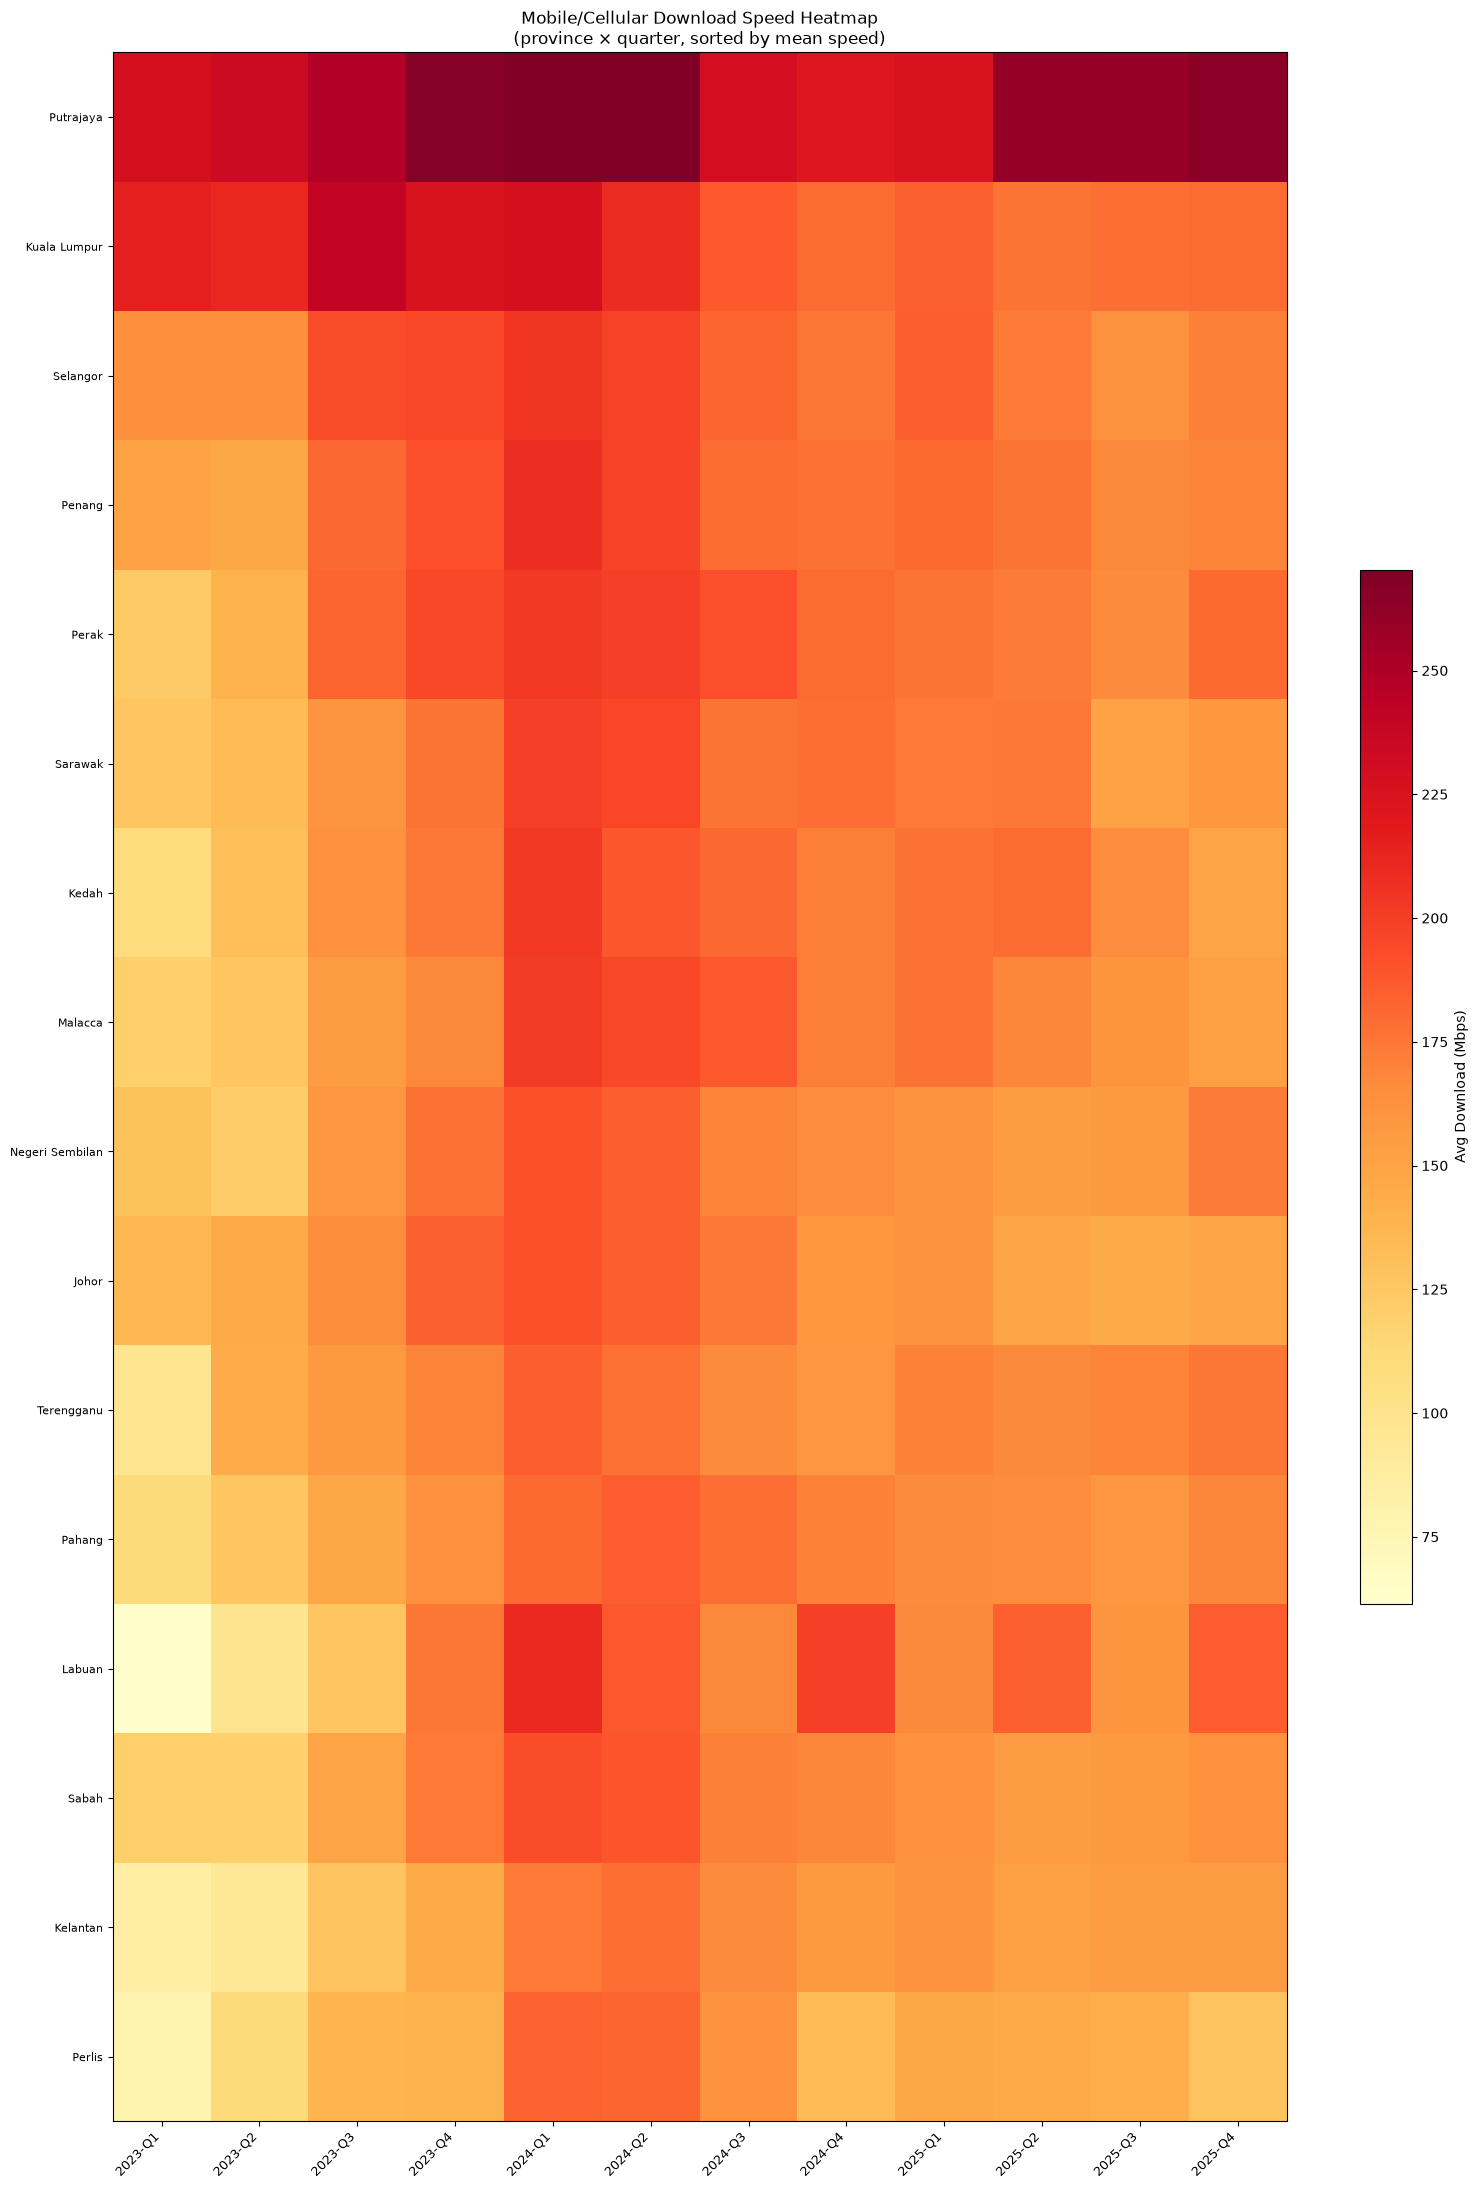

In [55]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

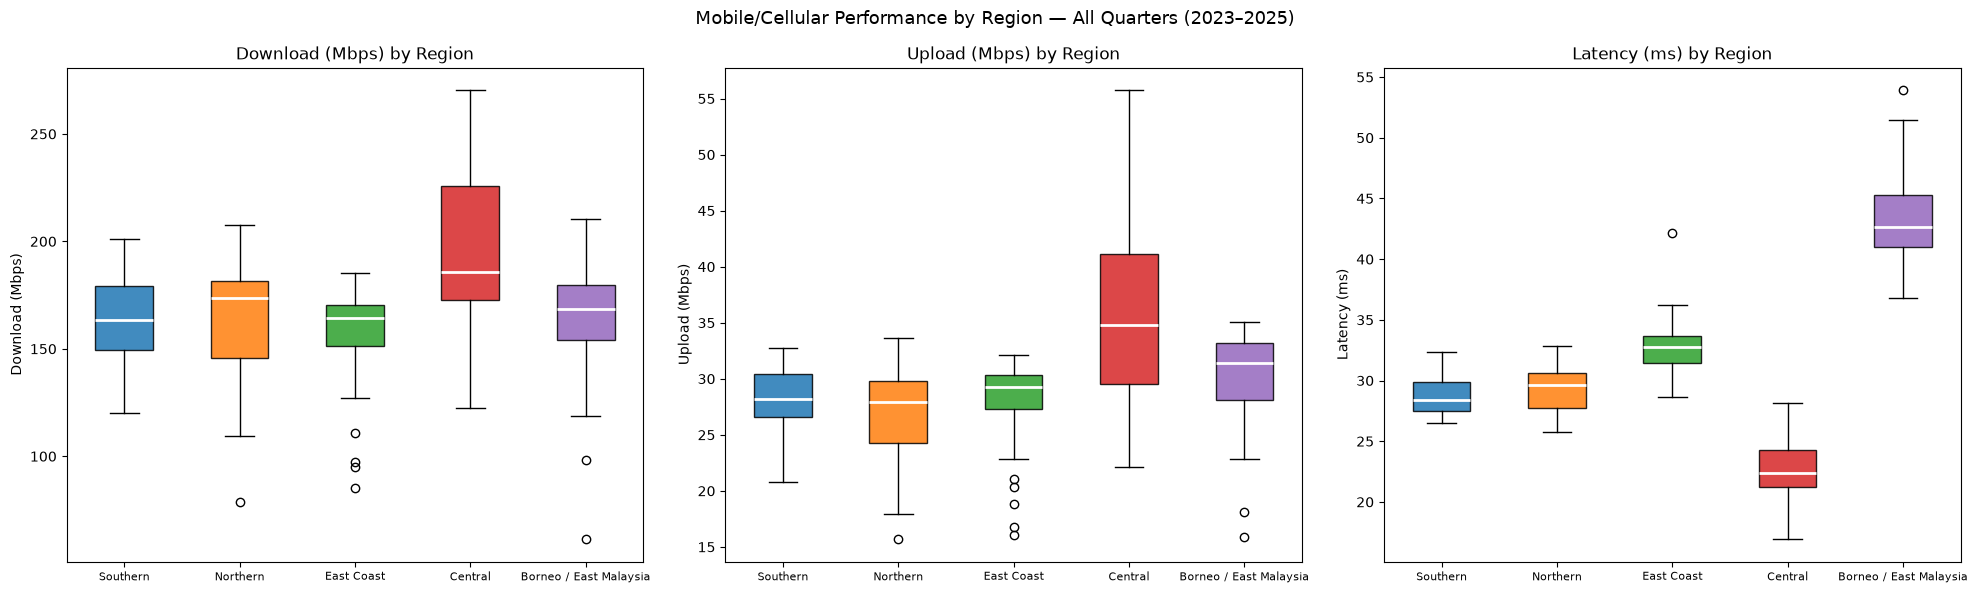

In [56]:
region_order = ['Southern', 'Northern', 'East Coast', 'Central', 'Borneo / East Malaysia']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

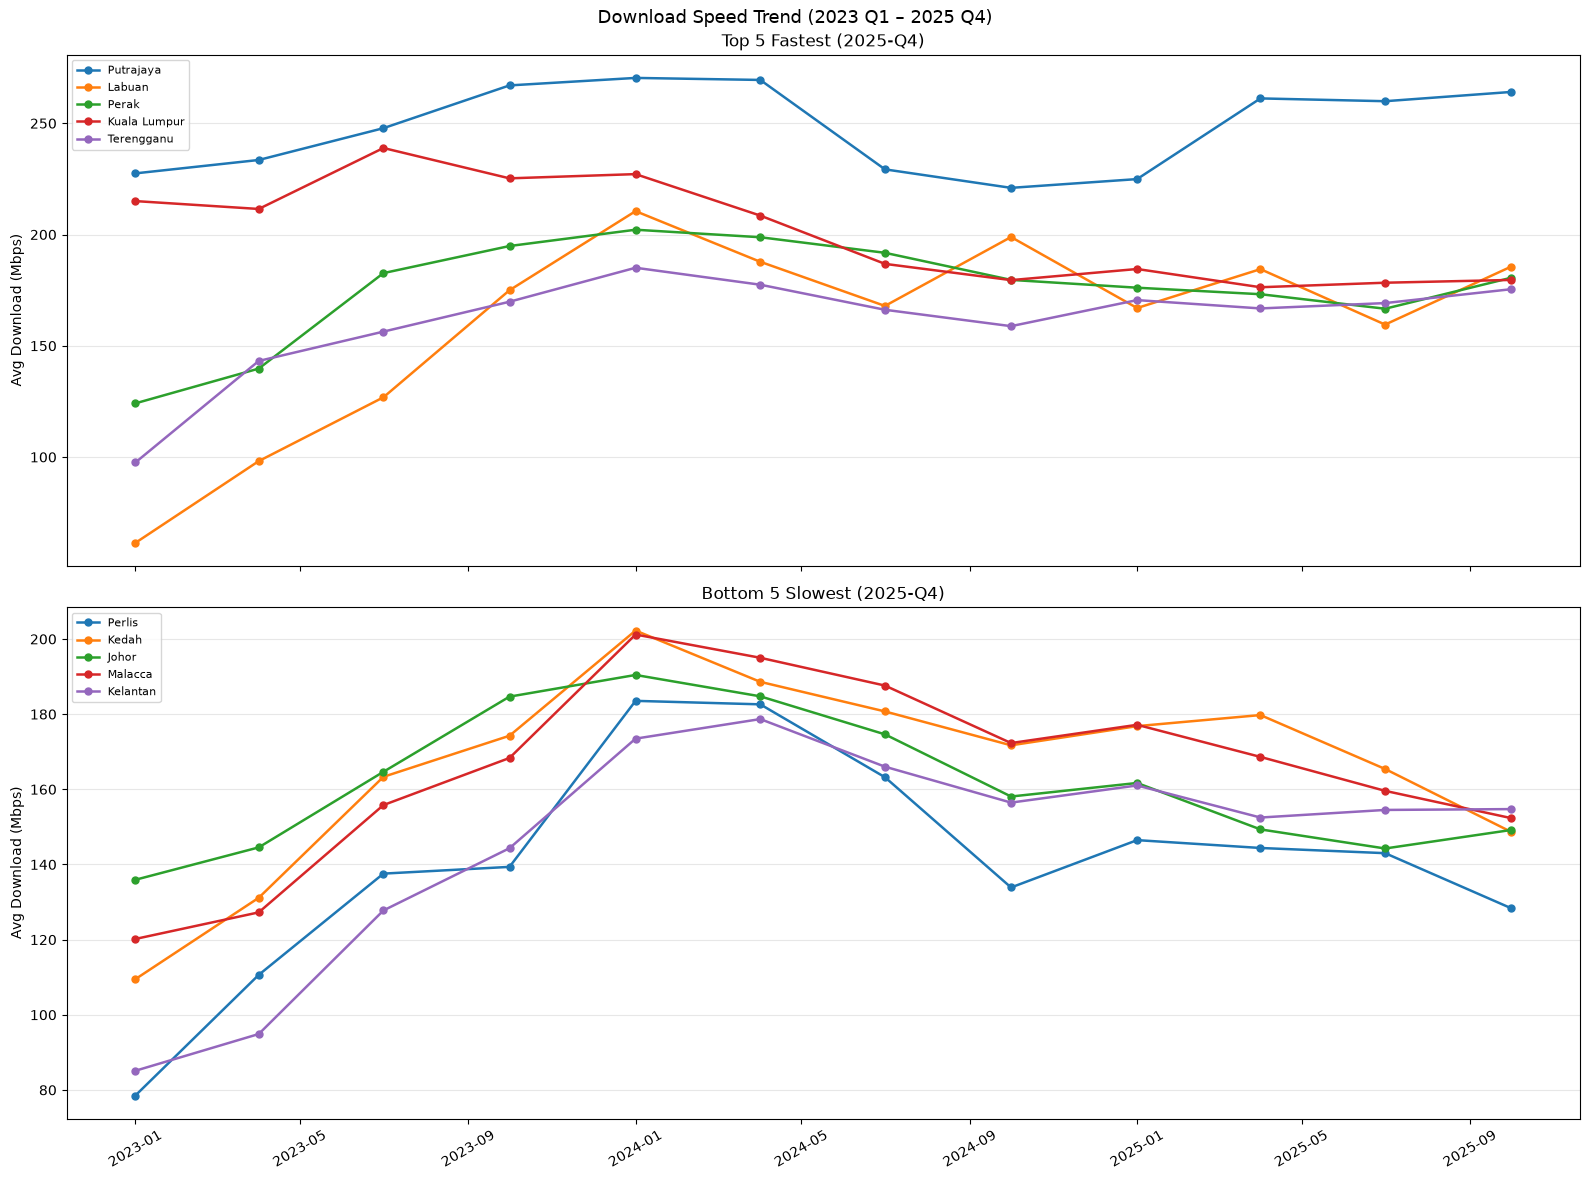

In [57]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

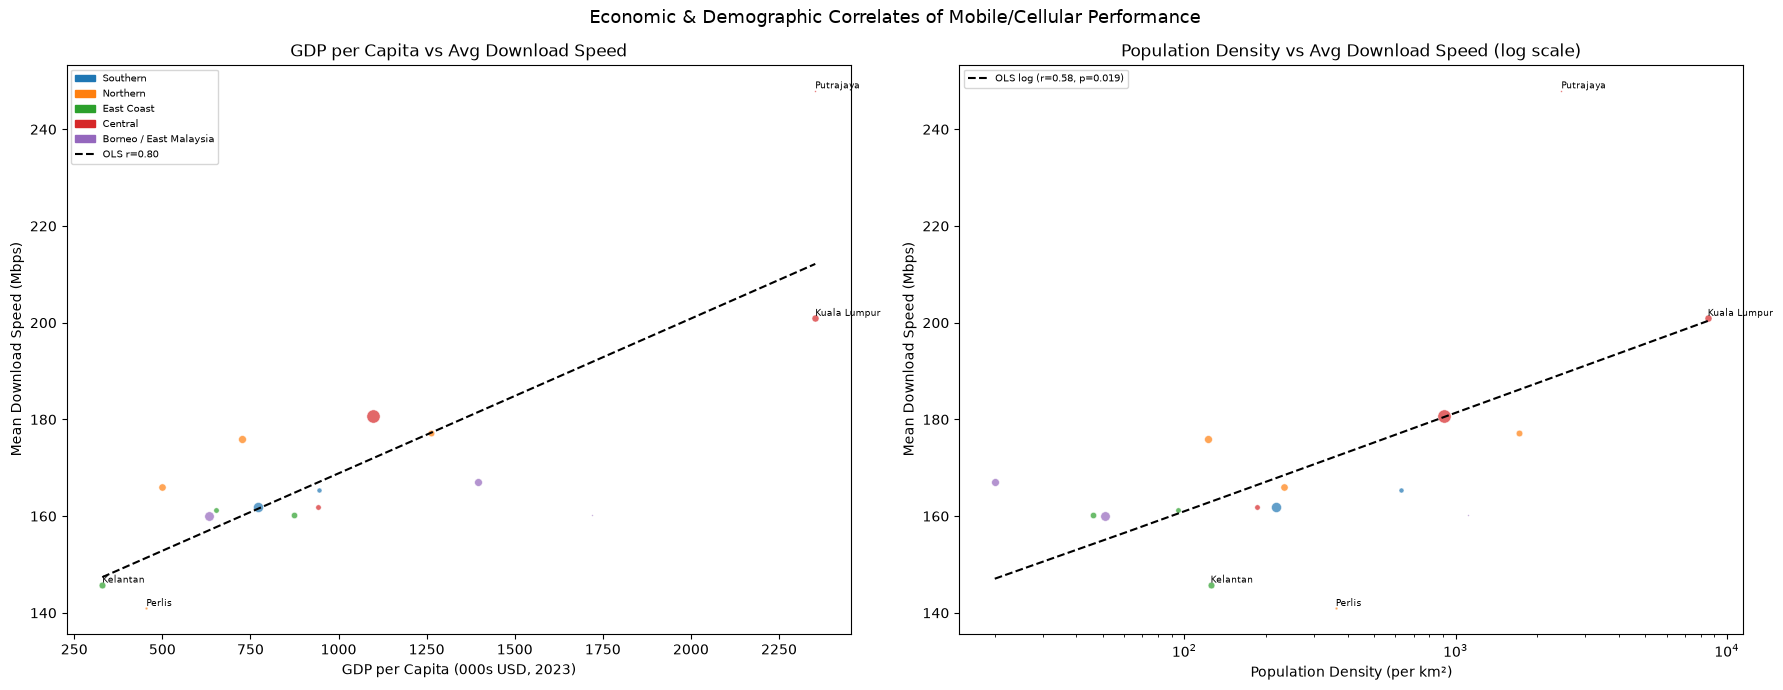

Pearson r (GDP vs download):     0.801  p=0.0002
Pearson r (log density vs download): 0.578  p=0.0190


In [58]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

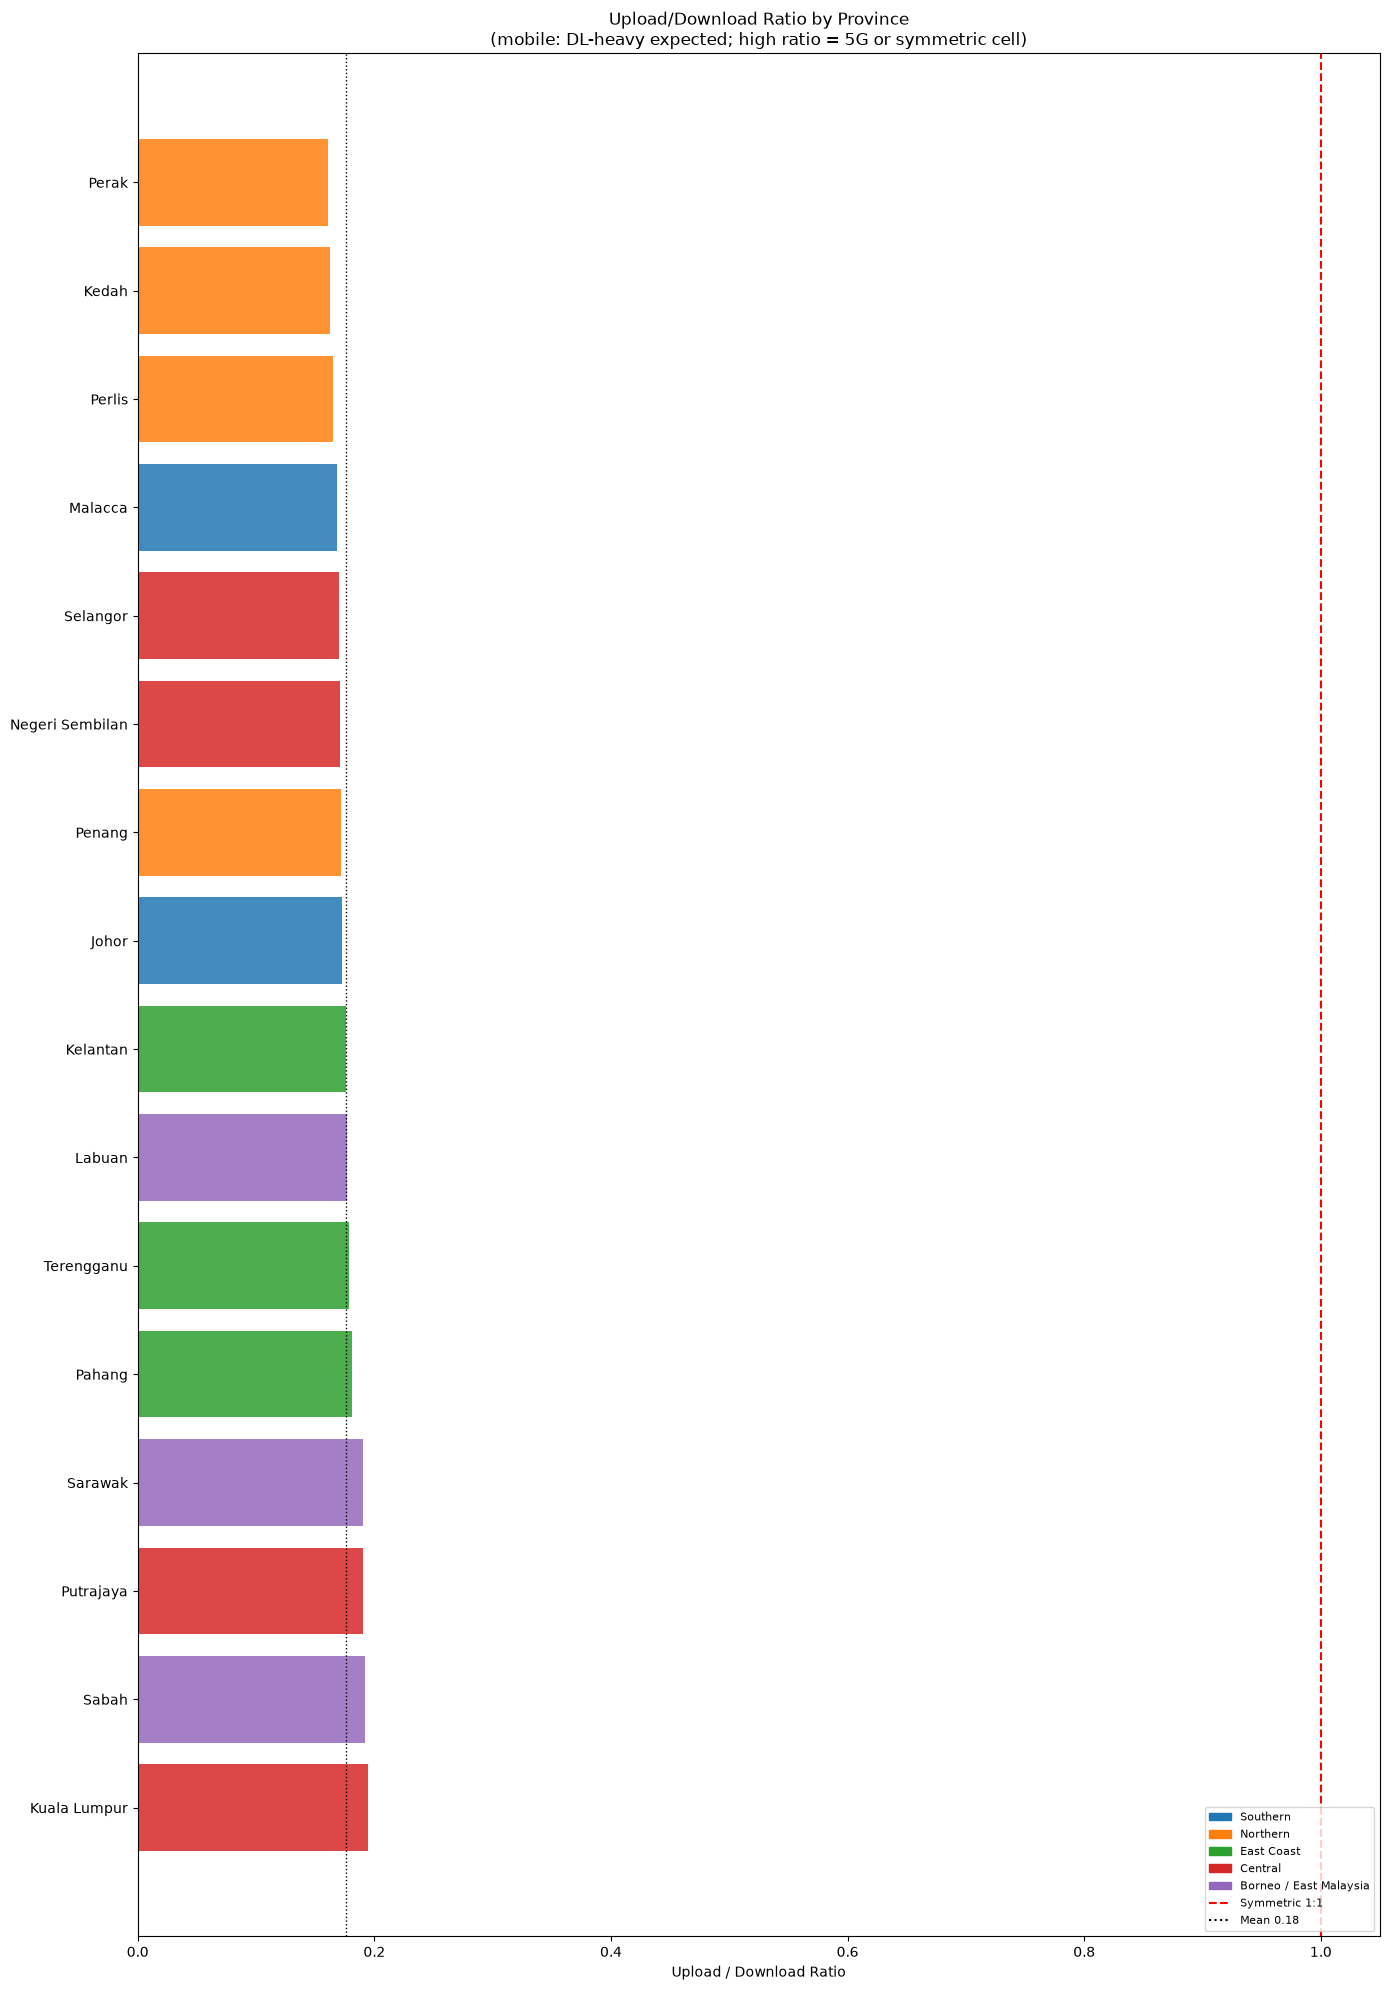

Provinces with UL/DL ratio > 0.5 (0):
Empty DataFrame
Columns: [name, region, ul_dl_ratio]
Index: []


In [59]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [60]:
# Per-province summary stats used by later sections (UL/DL ratio, tier median)

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


### 12. Full Province Summary Table

In [61]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

           name                 region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
      Putrajaya                Central              1   248.01    47.26     18.89         0.19     7925.67               2352939.20
   Kuala Lumpur                Central              1   200.95    38.79     22.39         0.20    89453.67               2352939.20
       Selangor                Central              2   180.61    30.59     22.27         0.17   222023.75               1097869.12
         Penang               Northern              2   177.12    30.32     27.33         0.17    60803.67               1261809.92
          Perak               Northern              3   175.86    28.11     28.92         0.16    70235.33                725960.64
        Sarawak Borneo / East Malaysia              1   167.01    31.66     44.70         0.19    88905.17               1394765.44
          Kedah               Northern              4   166.02    26.82     

### 13. UL/DL Symmetry — Mobile Network Quality Indicator

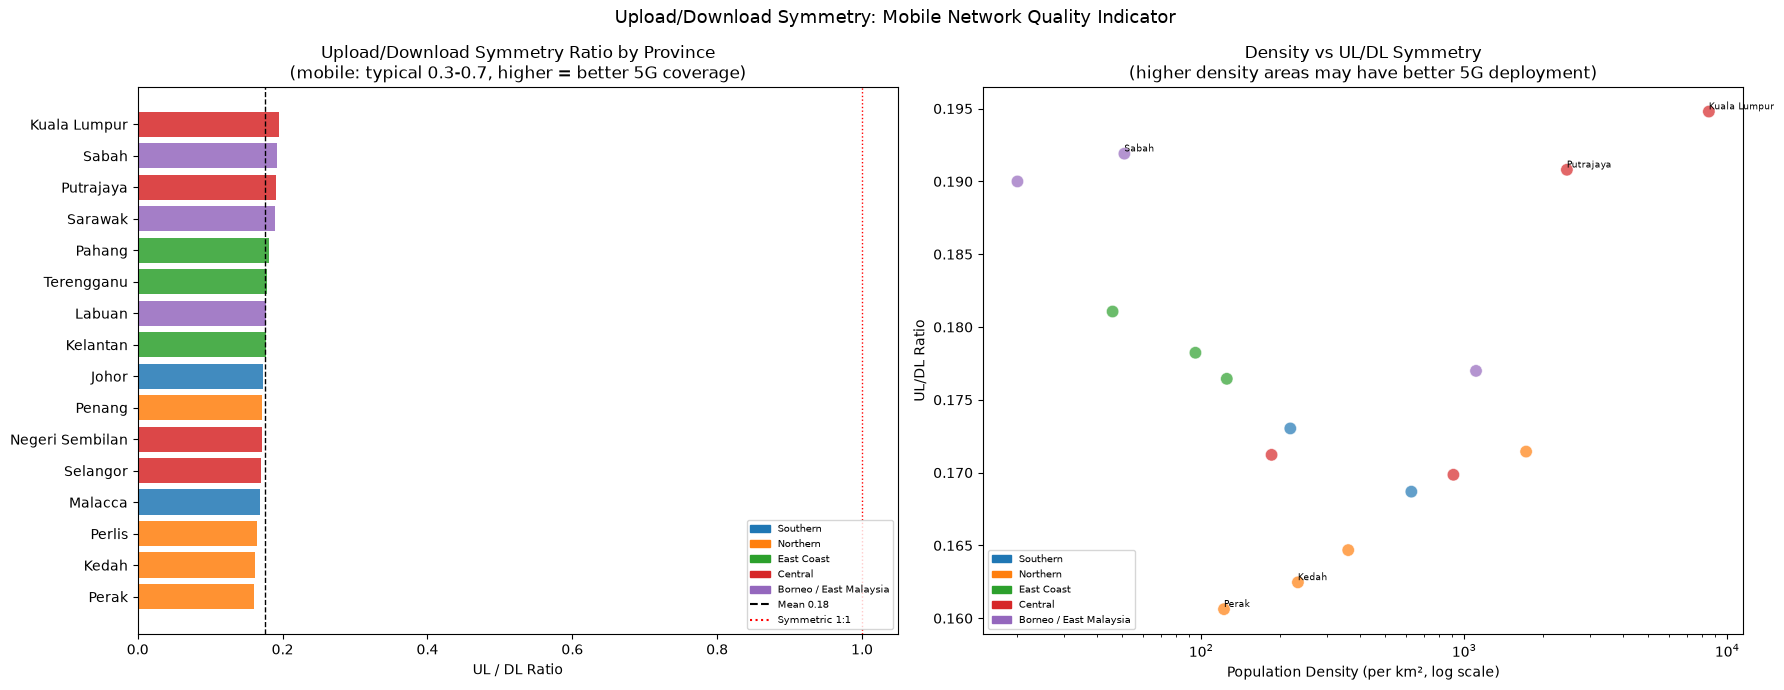

Provinces ratio > 0.5 (relatively symmetric mobile): 0 out of 16
Central mean ratio: 0.182
East Coast mean ratio: 0.179


In [62]:
# Mobile UL/DL ratio: typically 0.3-0.7 (DL-heavy by design)
# 5G NR can be more symmetric; high ratio may indicate 5G coverage

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(mobile: typical 0.3-0.7, higher = better 5G coverage)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1) or row['mean_dl'] > prov_mean['mean_dl'].quantile(0.9):
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\n(higher density areas may have better 5G deployment)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Mobile Network Quality Indicator', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.5 (relatively symmetric mobile): {(prov_mean['mean_ratio'] > 0.5).sum()} out of {len(prov_mean)}")
print(f"{_top_region} mean ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].mean():.3f}")
print(f"{_bot_region} mean ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].mean():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

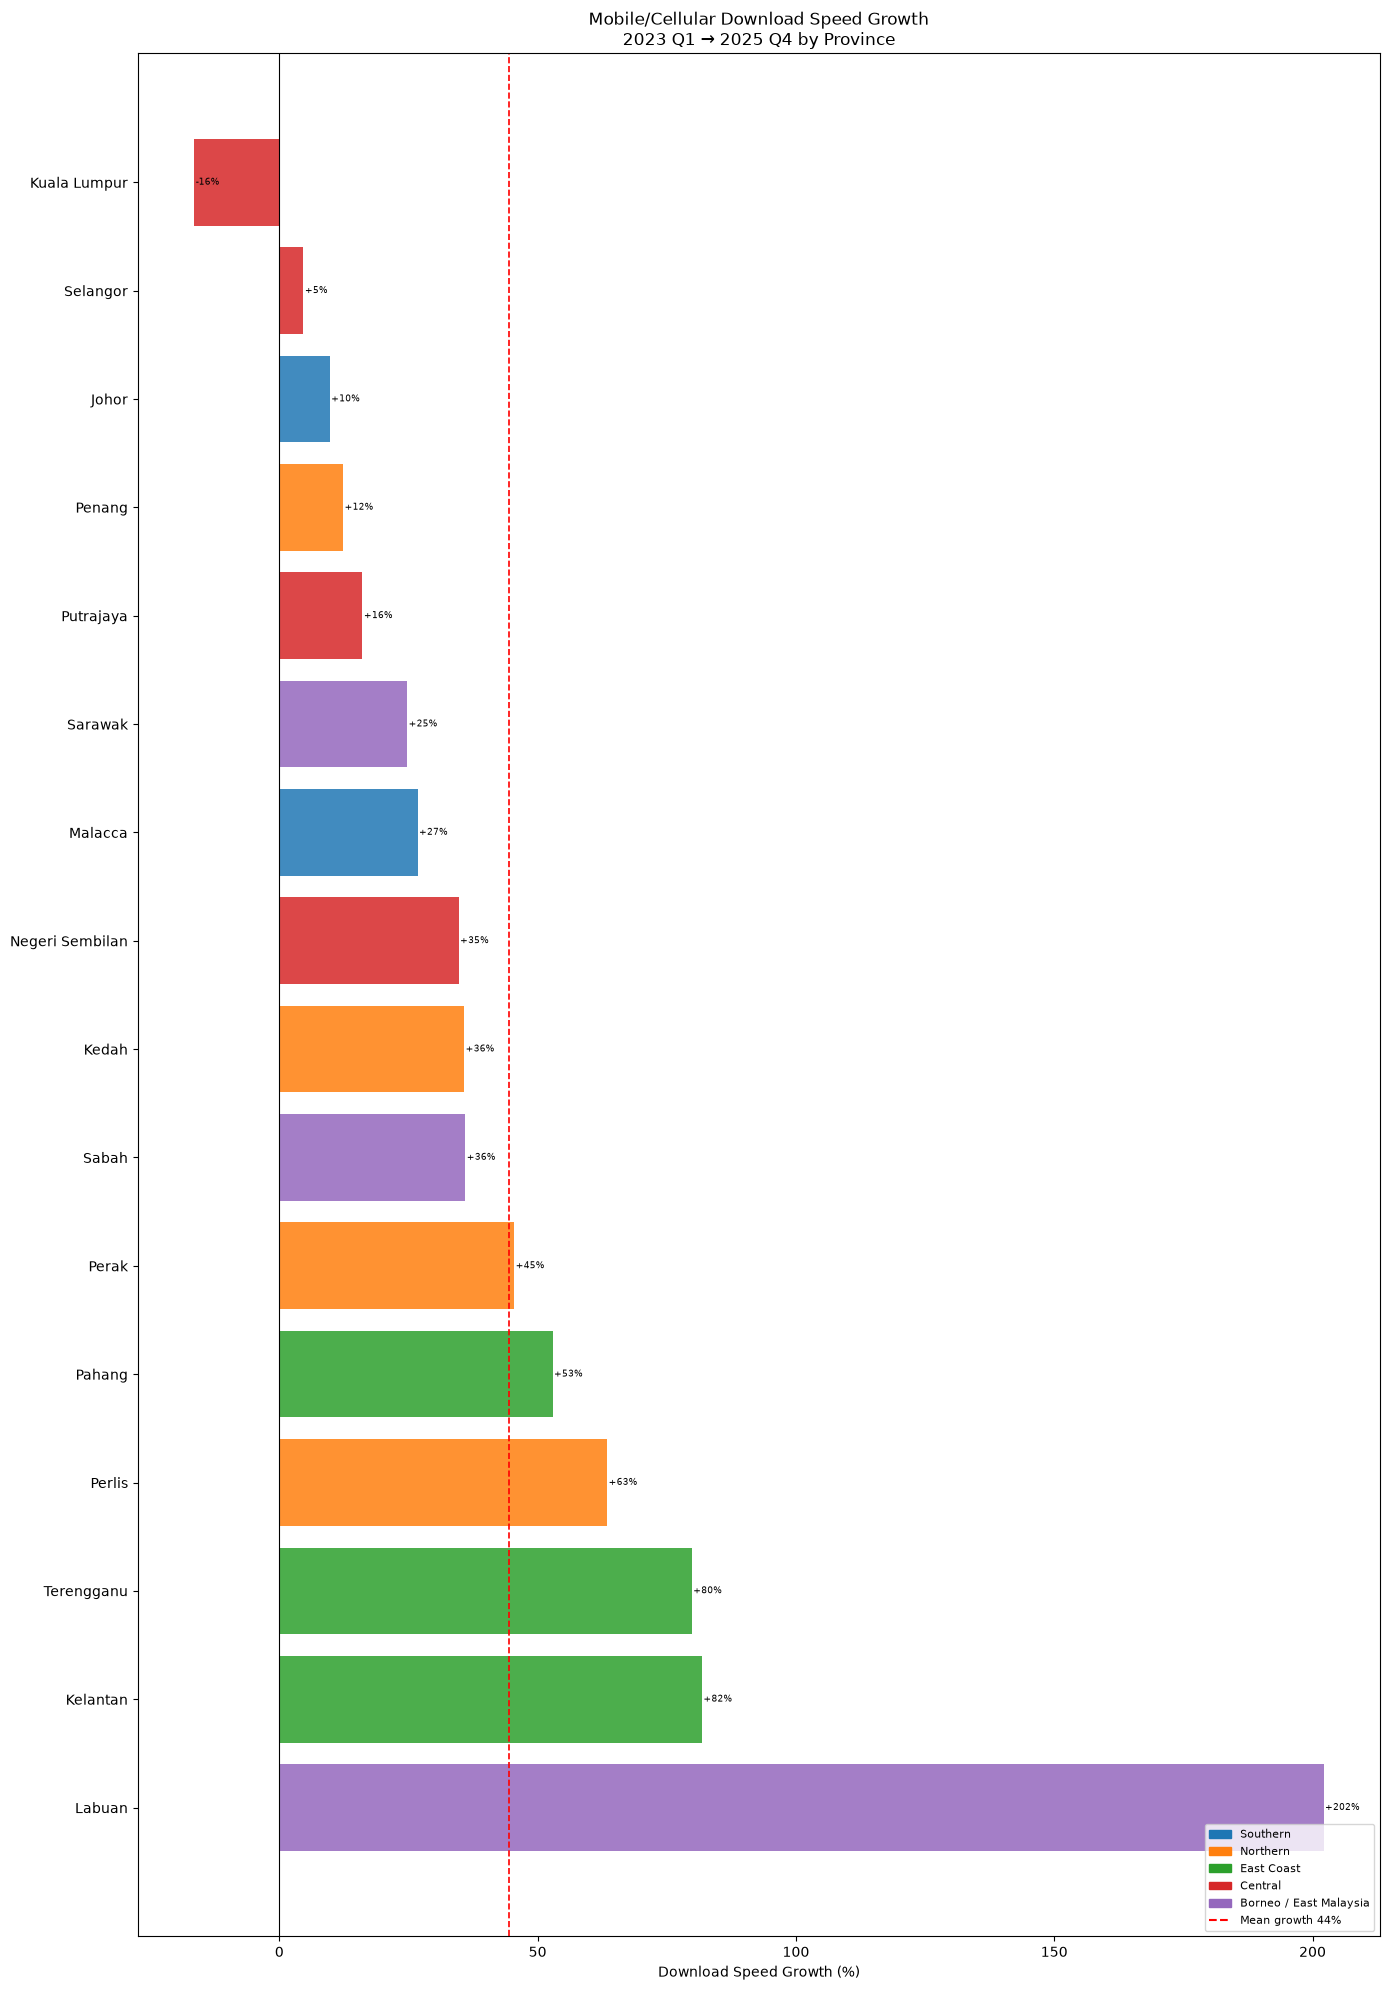

Top 10 fastest growing provinces:
           name                 region  internet_tier  pct_growth
         Labuan Borneo / East Malaysia              1  202.128812
       Kelantan             East Coast              4   81.803310
     Terengganu             East Coast              3   79.826605
         Perlis               Northern              4   63.455448
         Pahang             East Coast              3   52.884493
          Perak               Northern              3   45.471787
          Sabah Borneo / East Malaysia              4   35.997820
          Kedah               Northern              4   35.778436
Negeri Sembilan                Central              2   34.699011
        Malacca               Southern              2   26.751612

Bottom 5 (slowest growth or decline):
        name   region  internet_tier  pct_growth
Kuala Lumpur  Central              1  -16.480799
    Selangor  Central              2    4.666790
       Johor Southern              3    9.748418
     

In [63]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/malaysia/mobile/20_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 16. EDA Key Findings Summary

## Key Findings from EDA

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [74]:
# ── Export Ookla Mobile quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_mobile_malaysia_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 192 rows → ../../data/exports/ookla_mobile_malaysia_province_quarterly.csv
   province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable      region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0     Johor  2023-Q1  2023        1  135.933856   23.745313      29.802678     130173.0   6629.0         True    Southern              3   4186300                771125.44              218
1     Kedah  2023-Q1  2023        1  109.495531   20.049874      32.365549      59453.0   4421.0         True    Northern              4   2217500                498386.88              233
2  Kelantan  2023-Q1  2023        1   85.114537   16.055282      35.189815      38627.0   3480.0         True  East Coast              4   1888500                329456.96              125
